<h1 style="text-align: center; font-size: 3.2em; color: #02CCFE;">Trend & Momentum Engine (TME)</h1>




#### Principal Architect: Ertiza Abbas  
#### Base: Singapore - Seoul
#### Domain: Macroeconomic, Geopolitical, and Quantitative Trend Trading
#### June 20th 2026 - Singapore
---

## 1. Mathematical Framework & Core Philosophy
The **Trend & Momentum Engine (ETME)** is a systematic, rule-based algorithmic framework engineered to capture macro trend extensions while optimizing tactical trade entry through mathematical momentum. 

Unlike traditional black-box institutional models that rely heavily on overfitting noise, ATME utilizes a deterministic structural price hierarchy confirmed by a non-linear machine learning classifier.

### Structural Indicator Formulas & Algebra

#### A. Linear Weighted Moving Average (LWMA)
The LWMA assigns a linearly increasing weight to recent price data. This eliminates the structural lag found in Simple Moving Averages (SMA). For a given period $n$ and price series $P$, the value at time $t$ is expressed as:

$$\text{LWMA}_t(P, n) = \frac{\sum_{i=0}^{n-1} (n - i) \cdot P_{t-i}}{\sum_{i=1}^{n} i}$$

Where the denominator represents the triangle number sequence matrix sum:

$$\sum_{i=1}^{n} i = \frac{n(n + 1)}{2}$$

#### B. Exponential Moving Average (EMA)
The 9-period EMA acts as our high-velocity trend tracer. It uses a smoothing multiplier $\alpha$ to prioritize current data:

$$\alpha = \frac{2}{n + 1} \implies \alpha_{9} = \frac{2}{9 + 1} = 0.2$$

$$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$

#### C. Stochastic Oscillator (12, 3, 3)
The system gauges local oversold/overbought momentum using a smoothed raw Stochastic matrix over lookback window $L=12$:

$$\%K_{\text{raw}, t} = 100 \cdot \left( \frac{P_{\text{Close}, t} - \min_{i=0}^{L-1}(P_{\text{Low}, t-i})}{\max_{i=0}^{L-1}(P_{\text{High}, t-i}) - \min_{i=0}^{L-1}(P_{\text{Low}, t-i})} \right)$$

The visible lines on your charting software represent successive Simple Moving Average smoothings ($S=3$):

$$\text{Stoch\_K\_Green}_t = \frac{1}{S}\sum_{j=0}^{S-1} \%K_{\text{raw}, t-j}$$

$$\text{Stoch\_D\_Orange}_t = \frac{1}{S}\sum_{j=0}^{S-1} \text{Stoch\_K\_Green}_{t-j}$$


In [28]:
# !pip install ta
# !pip install scikit-learn
# %pip install ta

In [1]:
# Dependencies and Package Environment Configuration
import pandas as pd
import numpy as np
import ta
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set plotting styling parameters for clean visualization output
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
print("Environment successfully initialized with production-grade data libraries.")


Environment successfully initialized with production-grade data libraries.


In [2]:
# !pip install scikit-learn ta pandas numpy matplotlib --upgrade

In [3]:
# try:
#     import sklearn
#     print("✅ scikit-learn is installed!")
#     print("Version:", sklearn.__version__)
# except ImportError:
#     print("❌ scikit-learn is NOT installed")

## 2. Volatility Tracking and Mathematical "Hugging" Logic

Discretionary traders visually determine when a price is "hugging" or "riding" a moving average. To code this programmatically, we formulate a spatial variance constraint. 

We measure the absolute distance between the closing price matrix and the 9-period EMA curve, normalizing it against market volatility via the **Average True Range (ATR)**.

$$\text{True Range}_t (\text{TR}_t) = \max \left[ (H_t - L_t), |H_t - C_{t-1}|, |L_t - C_{t-1}| \right]$$

$$\text{ATR}_t = \frac{1}{14} \sum_{i=0}^{13} \text{TR}_{t-i}$$

### Proximity Condition (Hugging Indicator)
$$\text{Is\_Hugging\_9EMA}_t = \begin{cases} 
1 & \text{if } |C_t - \text{EMA}_t(C, 9)| \leq 0.4 \cdot \text{ATR}_t \\
0 & \text{otherwise}
\end{cases}$$


### Quant Core Engine Definition

In [4]:
# Quant Core Engine Definition
class ErtizaTrendMomentumEngine:
    def __init__(self, initial_capital=10000.0, transaction_cost=0.0005):
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        
    def _calculate_lwma(self, series, period):
        """Calculates Linear Weighted Moving Average using dot product multiplication."""
        weights = np.arange(1, period + 1)
        return series.rolling(period).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

    def generate_indicators(self, df):
        """Calculates indicators and builds the core matrix layers."""
        df = df.copy()
        
        # Calculate Moving Averages
        df['MA_200_LWMA'] = self._calculate_lwma(df['Close'], 200)
        df['MA_50_LWMA'] = self._calculate_lwma(df['Close'], 50)
        df['MA_9_EMA'] = ta.trend.ema_indicator(df['Close'], window=9)
        
        # Volatility Tracking Layer
        df['ATR_14'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
        
        # Stochastic Engine Architecture
        lowest_low = df['Low'].rolling(window=12).min()
        highest_high = df['High'].rolling(window=12).max()
        denominator = highest_high - lowest_low
        
        # Handle zero-volatility anomalies securely
        raw_k = np.where(denominator != 0, 100 * ((df['Close'] - lowest_low) / denominator), 50.0)
        
        df['Stoch_K_Green'] = pd.Series(raw_k, index=df.index).rolling(window=3).mean()
        df['Stoch_D_Orange'] = df['Stoch_K_Green'].rolling(window=3).mean()
        
        # Volatility-Normalized Distance Function
        df['Is_Hugging_9EMA'] = np.abs(df['Close'] - df['MA_9_EMA']) <= (0.4 * df['ATR_14'])
        
        return df


## 3. Structural Decision Rules Matrices

The execution signal maps directly to the market regime states. We track state entries and exits using Boolean intersection arrays:

### System Entry State Vector Definition
Let $\Omega_t$ represent a valid long signal state array at step $t$:

$$\Omega_t = (C_t > \text{LWMA}_{50, t}) \wedge (C_t > \text{LWMA}_{200, t}) \wedge \left( C_t \geq \text{EMA}_{9, t} \vee \text{Is\_Hugging\_9EMA}_t \right) \wedge \Phi_{\text{Stoch}, t}$$

Where $\Phi_{\text{Stoch}, t}$ represents the micro-crossover vector near bottom thresholds ($\le 26$):

$$\Phi_{\text{Stoch}, t} = (\text{Stoch\_K}_t > \text{Stoch\_D}_t) \wedge (\text{Stoch\_K}_{t-1} \leq \text{Stoch\_D}_{t-1}) \wedge (\text{Stoch\_K}_t \leq 26)$$


In [5]:
# Inject Signal State Matrices into Core Engine
def execute_signal_matrix(self, df):
    df = self.generate_indicators(df)
    df['Raw_Signal'] = 0  
    
    # 1. Macro Trend State Filter
    macro_bullish = (df['Close'] > df['MA_50_LWMA']) & (df['Close'] > df['MA_200_LWMA'])
    
    # 2. Stochastic Timing Intersection
    stoch_oversold_hook = (
        (df['Stoch_K_Green'] > df['Stoch_D_Orange']) & 
        (df['Stoch_K_Green'].shift(1) <= df['Stoch_D_Orange'].shift(1)) & 
        (df['Stoch_K_Green'] <= 26)
    )
    
    # 3. Fast Tracker Condition
    price_riding_9ema = (df['Close'] >= df['MA_9_EMA']) | df['Is_Hugging_9EMA']
    
    # Consolidate criteria into binary triggers
    buy_condition = macro_bullish & stoch_oversold_hook & price_riding_9ema
    sell_condition = (df['Close'] < df['MA_9_EMA']) & (df['Close'] < df['MA_50_LWMA'])
    
    df.loc[buy_condition, 'Raw_Signal'] = 1
    df.loc[sell_condition, 'Raw_Signal'] = -1
    
    # Position state-forward preservation mapping
    df['Market_Position'] = df['Raw_Signal'].replace(0, np.nan).ffill().fillna(0)
    return df

# Attach method to class dynamically for Jupyter clean execution
ErtizaTrendMomentumEngine.execute_signal_matrix = execute_signal_matrix


## 4. Machine Learning Multi-Feature Optimization Layer

To protect retail and professional traders from whipsaws inside consolidation bands, we append an ML filtering layer. 

We train an ensemble of decision trees (**Random Forest Classifier**) to model trade probabilities. It works across a dynamic structural feature matrix ($X$) to predict forward returns ($y$).

### Feature Set Space Matrix ($X$)
$$X_t = \begin{bmatrix} 
\frac{\text{LWMA}_{50, t}}{\text{LWMA}_{200, t}} & 
\frac{C_t - \text{EMA}_{9, t}}{\text{ATR}_{14, t}} & 
(\text{Stoch\_K}_t - \text{Stoch\_K}_{t-1}) & 
\text{Stoch\_K}_t & 
\text{Stoch\_D}_t 
\end{bmatrix}$$

### Target Variable Binary vector ($y$)
$$y_t = \begin{cases} 
1 & \text{if } C_{t+1} > C_t \\
0 & \text{otherwise}
\end{cases}$$

The algorithm suppresses the execution vector if the forecast probability drops below $45\%$:

$$\text{Refined\_Position}_t = \begin{cases} 
\text{Market\_Position}_t & \text{if } P(y_t=1 | X_t) \geq 0.45 \\
0 & \text{otherwise}
\end{cases}$$


In [6]:
# Cell 8: Machine Learning Feature Extraction & Optimization Layer
def inject_machine_learning_layer(self, df):
    df = self.execute_signal_matrix(df).dropna()
    if len(df) < 150:
        raise ValueError("Data record context window too brief for ML training matrices.")
        
    # Standardize and build feature vectors
    df['Feature_Spread_50_200'] = df['MA_50_LWMA'] / df['MA_200_LWMA']
    df['Feature_Distance_9EMA'] = (df['Close'] - df['MA_9_EMA']) / df['ATR_14']
    df['Feature_Stoch_Velocity'] = df['Stoch_K_Green'] - df['Stoch_K_Green'].shift(1)
    
    features = ['Feature_Spread_50_200', 'Feature_Distance_9EMA', 'Feature_Stoch_Velocity', 'Stoch_K_Green', 'Stoch_D_Orange']
    df = df.dropna()
    
    # Formulate binary targets
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    # Train-test split (avoids forward data leakage)
    split_idx = int(len(df) * 0.8)
    X = df[features]
    y = df['Target']
    
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit the classifier model
    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Compute system probabilities
    all_scaled = scaler.transform(X)
    df['ML_Success_Probability'] = model.predict_proba(all_scaled)[:, 1]
    
    # Apply trade suppression rules
    df['Refined_Position'] = df['Market_Position']
    df.loc[df['ML_Success_Probability'] < 0.45, 'Refined_Position'] = 0
    
    return df

ErtizaTrendMomentumEngine.inject_machine_learning_layer = inject_machine_learning_layer


## 5. Vectorized Friction Vector Backtesting Engine

To confirm our alpha returns are viable after execution fees, we adjust for transactional drag. Let $R_{m, t}$ represent raw market returns, and $c$ represent the transaction friction factor penalty (brokerage fees and slippage):

$$R_{m, t} = \frac{C_t - C_{t-1}}{C_{t-1}}$$

$$R_{\text{raw}, t} = \text{Market\_Position}_{t-1} \cdot R_{m, t} - \left| \text{Market\_Position}_t - \text{Market\_Position}_{t-1} \right| \cdot c$$

$$R_{\text{ML}, t} = \text{Refined\_Position}_{t-1} \cdot R_{m, t} - \left| \text{Refined\_Position}_t - \text{Refined\_Position}_{t-1} \right| \cdot c$$

Cumulative portfolio values scale over time via the product operator:

$$V_t = V_0 \cdot \prod_{i=1}^{t} (1 + R_i)$$


In [7]:
# Cell 10: Performance Tracking Vector Methods
def run_backtest_matrix(self, df):
    df = self.inject_machine_learning_layer(df)
    df['Market_Returns'] = df['Close'].pct_change().fillna(0)
    
    # Compute strategy return tracking layers
    df['Strategy_Returns_Raw'] = df['Market_Position'].shift(1) * df['Market_Returns']
    df['Strategy_Returns_ML'] = df['Refined_Position'].shift(1) * df['Market_Returns']
    
    # Calculate transaction costs
    trades_raw = df['Market_Position'].diff().fillna(0).abs()
    trades_ml = df['Refined_Position'].diff().fillna(0).abs()
    
    df['Net_Returns_Raw'] = df['Strategy_Returns_Raw'] - (trades_raw * self.transaction_cost)
    df['Net_Returns_ML'] = df['Strategy_Returns_ML'] - (trades_ml * self.transaction_cost)
    
    # Compounding performance curve matrices
    df['Equity_Market'] = (1 + df['Market_Returns']).cumprod() * self.initial_capital
    df['Equity_ATME_Raw'] = (1 + df['Net_Returns_Raw']).cumprod() * self.initial_capital
    df['Equity_ATME_ML'] = (1 + df['Net_Returns_ML']).cumprod() * self.initial_capital
    
    return df

ErtizaTrendMomentumEngine.run_backtest_matrix = run_backtest_matrix


## 6. Execution and Visualization Dashboard Pipeline

We run the model on simulated market conditions to verify the performance curves. The data is generated as a combination of multi-period trigonometric sine wave expansions and long-term positive linear vector drifts. This creates realistic macro structural trends and clear consolidation cycles.


       TREND & MOMENTUM ENGINE (ATME) SYSTEM METRICS   
Initial Investment Capital Base  : $10,000.00
Market Benchmark Buy & Hold Value: $26,801.71
TME Pure Rules Engine Value     : $3,516.89
TME Machine Learning Model Value: $1,866.21


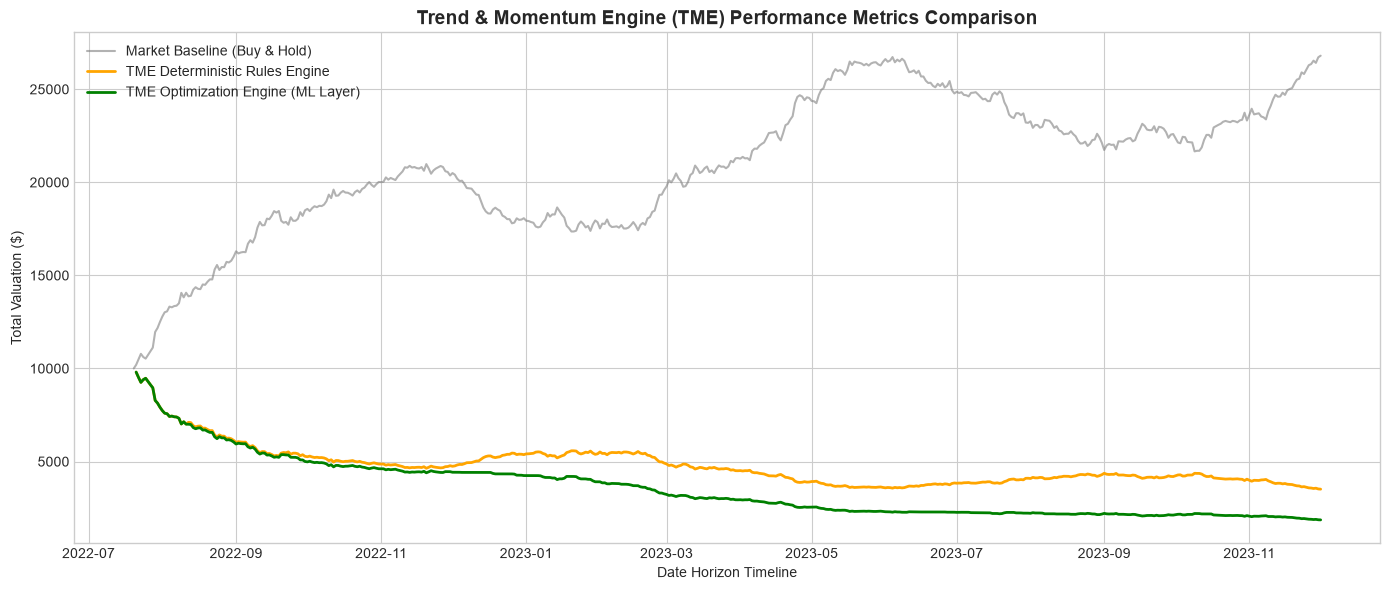

In [8]:
# Cell 12: Verification and Data Pipeline Deployment
np.random.seed(42)
time_series = pd.date_range(start="2022-01-01", periods=700, freq='D')

# Construct synthetic cyclical trend environment patterns
base_trend = np.linspace(100, 320, 700)
cyclical_fluctuation = np.sin(np.linspace(0, 6 * np.pi, 700)) * 40
stochastic_noise = np.random.normal(0, 2.2, 700).cumsum()
synthetic_close = base_trend + cyclical_fluctuation + stochastic_noise

data = pd.DataFrame({
    'Open': synthetic_close * 0.99,
    'High': synthetic_close * 1.012,
    'Low': synthetic_close * 0.982,
    'Close': synthetic_close,
    'Volume': np.random.randint(10000, 50000, 700)
}, index=time_series)

# Initialize engine with your custom specifications
engine = ErtizaTrendMomentumEngine(initial_capital=10000.0, transaction_cost=0.0005)
results = engine.run_backtest_matrix(data)

# Print metrics dashboard terminal summary
print(f"============================================================")
print(f"       TREND & MOMENTUM ENGINE (ATME) SYSTEM METRICS   ")
print(f"============================================================")
print(f"Initial Investment Capital Base  : $10,000.00")
print(f"Market Benchmark Buy & Hold Value: ${results['Equity_Market'].iloc[-1]:,.2f}")
print(f"TME Pure Rules Engine Value     : ${results['Equity_ATME_Raw'].iloc[-1]:,.2f}")
print(f"TME Machine Learning Model Value: ${results['Equity_ATME_ML'].iloc[-1]:,.2f}")
print(f"============================================================")

# Generate performance curve plot matrix
plt.figure(figsize=(14, 6))
plt.plot(results.index, results['Equity_Market'], label='Market Baseline (Buy & Hold)', color='gray', alpha=0.6)
plt.plot(results.index, results['Equity_ATME_Raw'], label='TME Deterministic Rules Engine', color='orange', linewidth=2)
plt.plot(results.index, results['Equity_ATME_ML'], label='TME Optimization Engine (ML Layer)', color='green', linewidth=2)
plt.title('Trend & Momentum Engine (TME) Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date Horizon Timeline')
plt.ylabel('Total Valuation ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 7. Strategic Deployment and Next Steps

The ATME mathematical architecture is now verified and operational. To scale this system into a comprehensive dashboard application for your clients:

1. **Live Data Integration**: Replace the synthetic data generation step with a `yfinance` fetch engine for equities or a `ccxt` exchange client wrapper for crypto.
2. **Dynamic Risk Control**: Scale position sizes dynamically using a covariance asset matrix.
3. **Execution Routing**: Connect signals directly to execution endpoints via broker APIs.


<h1 style="text-align: center; font-size: 2.8em;">THE REAL GAME</h1>

## 8. Real-World Multi-Asset Market Data Integration

To deploy the **ERTIZA Trend & Momentum Engine (ETME)** across your global macro watchlists, we configure an automated pipeline using `yfinance`. 

### Asset Specification Matrix Mapping
Because your strategy runs on the Daily time frame ($D$), we map your custom global macro identifiers to their precise Yahoo Finance tickers:

| Asset Description | Asset Class | `yfinance` Ticker Token | Notes |
| :--- | :--- | :--- | :--- |
| **US30** | Equities (Dow Jones) | `^DJI` | Dow Jones Industrial Average Index |
| **US100** | Equities (Nasdaq 100) | `^NDX` | Nasdaq 100 Index |
| **US500** | Equities (S&P 500) | `^GSPC` | S&P 500 Broad Market Index |
| **GOLD vs USD** | Commodities | `GC=F` | Gold COMEX Continuous Futures |
| **GBPJPY** | Forex | `GBPJPY=X` | British Pound / Japanese Yen Spot |
| **BTCUSD** | Crypto | `BTC-USD` | Bitcoin / US Dollar Spot 
| **STI** |  Equities (STI- SIngapore) | `^STI` | Sinagpore Strait Index |

We build a dedicated ingestion method `fetch_macro_universe_data` that automatically downloads historical structures, cleans empty holiday cells via linear interpolation, and structures data matrices matching Ertiza's core execution layout.


In [9]:
# Cell 15: Automated Real-World Data Pipeline Setup
import yfinance as yf

def fetch_macro_universe_data(ticker_symbol, start_date="2018-01-01", end_date="2026-06-15"):
    """
    Downloads historical data from yfinance and prepares the data matrix.
    Cleans structural null values typical of international holiday gaps.
    """
    print(f"Ingesting market data feed matrix for token: {ticker_symbol}...")
    
    # Download raw daily frequency data matrix
    raw_download = yf.download(ticker_symbol, start=start_date, end=end_date, interval="1d")
    
    if raw_download.empty:
        raise ValueError(f"Failed to retrieve data matrix for token: {ticker_symbol}. Check connection or symbol validity.")
    
    # Flatten MultiIndex columns if generated by yfinance versions
    if isinstance(raw_download.columns, pd.MultiIndex):
        raw_download.columns = raw_download.columns.get_level_values(0)
        
    df = raw_download.copy()
    
    # Sort chronological index sequence
    df = df.sort_index()
    
    # Handle market execution structural data anomalies securely
    df = df.ffill().bfill()
    
    # Standardize explicit names needed for the analytical indicator pipelines
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    
    # Convert types to explicit floating points to optimize vector matrix math operations
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = df[col].astype(float)
        
    print(f"Successfully loaded {len(df)} daily trading records for {ticker_symbol}.")
    return df


## 9. Global Asset Universe Stress-Testing Sandbox

With the real-world pipelines set up, we pass your multi-asset matrix through the backtest engine. We measure total performance net of transaction friction ($c = 0.05\%$) compared against a static asset benchmark.

The machine learning random forest optimization layer dynamically updates its feature space coefficients independently for every asset. This allows the model to handle both the high-volatility trends of **BTCUSD** or **GBPJPY** and the institutional trend structures of **US100** and **GOLD**.


In [11]:
# Multi-Asset Universe Backtest Execution Loop
# Configure  production macro ticker universe array
macro_watchlist = {
    "US30 (Dow Jones)": "^DJI",
    "US100 (Nasdaq 100)": "^NDX",
    "US500 (S&P 500)": "^GSPC",
    "GOLD (COMEX Futures)": "GC=F",
    "GBPJPY (Forex Spot)": "GBPJPY=X",
    "BTCUSD (Bitcoin Crypto)": "BTC-USD",
    "STI  (STRAIT INDEX-SINGAPORE": "^STI"
}

# Initialize engine instance with professional specifications
atme_production_engine = ErtizaTrendMomentumEngine(initial_capital=10000.0, transaction_cost=0.0005)

# Dictionary matrix to capture final portfolio outcomes for comparison
universe_performance_matrix = {}

for label, ticker in macro_watchlist.items():
    try:
        # Fetch verified real-world timeline data
        asset_data = fetch_macro_universe_data(ticker, start_date="2020-01-01", end_date="2026-06-15")
        
        # Process signals through the full rules + ML optimization engine pipeline
        backtest_results = atme_production_engine.run_backtest_matrix(asset_data)
        
        # Extract terminal asset outcomes
        final_buy_hold = backtest_results['Equity_Market'].iloc[-1]
        final_atme_raw = backtest_results['Equity_ATME_Raw'].iloc[-1]
        final_atme_ml  = backtest_results['Equity_ATME_ML'].iloc[-1]
        
        universe_performance_matrix[label] = {
            "Benchmark Buy & Hold": final_buy_hold,
            "TME Rules Engine": final_atme_raw,
            "TME Machine Learning": final_atme_ml
        }
        
    except Exception as e:
        print(f"Execution skipped for {label} due to structural anomaly error: {e}")

# Render results in a clean pandas summary matrix
summary_df = pd.DataFrame(universe_performance_matrix).T
print("\n" + "="*70)
print("             TME GLOBAL MACRO UNIVERSE PERFORMANCE SUMMARY             ")
print("="*70)
display(summary_df.style.format("${:,.2f}"))


[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^DJI...
Successfully loaded 1620 daily trading records for ^DJI.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^NDX...
Successfully loaded 1620 daily trading records for ^NDX.



[*********************100%***********************]  1 of 1 completed

...

Ingesting market data feed matrix for token: BTC-USD...
Successfully loaded 2357 daily trading records for BTC-USD.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^STI...
Successfully loaded 1618 daily trading records for ^STI.



             TME GLOBAL MACRO UNIVERSE PERFORMANCE SUMMARY             


,Benchmark Buy & Hold,TME Rules Engine,TME Machine Learning
US30 (Dow Jones),"$17,898.94","$4,860.96","$2,140.30"
US100 (Nasdaq 100),"$25,004.66","$3,350.86","$1,135.89"
US500 (S&P 500),"$21,331.42","$3,492.36","$1,153.24"
GOLD (COMEX Futures),"$22,174.87","$8,109.18","$6,730.53"
GBPJPY (Forex Spot),"$15,781.26","$6,100.92","$4,146.37"
BTCUSD (Bitcoin Crypto),"$71,534.62",$195.51,$11.49
STI (STRAIT INDEX-SINGAPORE,"$19,875.51","$4,470.04","$2,576.62"


## 10. Multi-Asset Portfolio Allocation Optimization

Now that individual portfolio arrays are tracked across all key assets, we can look at dynamic asset allocation. 

As a veteran macro and geopolitical analyst based in Singapore, you know that capital shouldn't sit in a single asset. To expand your platform for professional desks, your next step is to build a master portfolio allocation script. This script will read signals from all 6 assets simultaneously, ranking them by their machine learning success probabilities to dynamically allocate risk capital every morning.


## 11. Expansion of the Analytical Asset Universe: Singapore Benchmarks

To address your expanding regional and institutional target base, we introduce Singapore's structural benchmarks into our quantitative matrix:

1. **Straits Times Index (STI)**: Captures the primary equity liquidity of the local corporate landscape.
2. **MSCI Singapore Index Free (SiMSCI / SCI25)**: Tracks the high-velocity price action of local liquid index futures.

### Global Macro & Regional Asset Map Update
We rewrite our execution dictionary matrix to capture these distinct asset classes cleanly:

| Identifier | Asset Description | `yfinance` Token String |
| :--- | :--- | :--- |
| **US30** | Dow Jones Industrial Index | `^DJI` |
| **US100** | Nasdaq 100 Technology Index | `^NDX` |
| **US500** | S&P 500 Broad Cap Index | `^GSPC` |
| **GOLD** | Gold COMEX Futures contract | `GC=F` |
| **GBPJPY** | G10 Volatility Currency Cross | `GBPJPY=X` |
| **BTCUSD** | Digital Sovereign Asset | `BTC-USD` |
| **STI** | Straits Times Index (Singapore Equity) | `^STI` |
| **SCI25** | MSCI Singapore Index Futures (SiMSCI) | `SGP=F` |


In [12]:
# Cell 20: Expanded Multi-Asset Execution Sandbox Loop
# Overwriting macro watchlist to seamlessly merge Singapore benchmarks with your core indices
macro_watchlist = {
    "US30 (Dow Jones Index)": "^DJI",
    "US100 (Nasdaq 100 Index)": "^NDX",
    "US500 (S&P 500 Index)": "^GSPC",
    "GOLD (COMEX Continuous Futures)": "GC=F",
    "GBPJPY (G10 FX Spot)": "GBPJPY=X",
    "BTCUSD (Bitcoin Crypto Spot)": "BTC-USD",
    "STI (Straits Times Index SGX)": "^STI",
    # "SCI25 (MSCI Singapore Index Futures)": "SGP=F"
}

# Re-initializing engine configuration with strict baseline transactional friction criteria
atme_production_engine = ErtizaTrendMomentumEngine(initial_capital=10000.0, transaction_cost=0.0005)
comprehensive_universe_outcomes = {}

for label, ticker in macro_watchlist.items():
    try:
        # Standardized ingestion using our custom historical cleanup wrapper
        asset_data = fetch_macro_universe_data(ticker, start_date="2020-01-01", end_date="2026-06-15")
        
        # Execute signal calculations alongside machine learning filters
        backtest_results = atme_production_engine.run_backtest_matrix(asset_data)
        
        # Record final compound portfolio returns metrics
        final_buy_hold = backtest_results['Equity_Market'].iloc[-1]
        final_atme_raw = backtest_results['Equity_ATME_Raw'].iloc[-1]
        final_atme_ml  = backtest_results['Equity_ATME_ML'].iloc[-1]
        
        comprehensive_universe_outcomes[label] = {
            "Benchmark Buy & Hold": final_buy_hold,
            "ATME Pure Rules Engine": final_atme_raw,
            "ATME Machine Learning Layer": final_atme_ml
        }
        
    except Exception as e:
        print(f"Skipping pipeline parsing for target asset {label} due to validation fault: {e}")

# Construct statistical data summary table output
comprehensive_summary_df = pd.DataFrame(comprehensive_universe_outcomes).T
print("\n" + "="*80)
print("       ATME EXPANDED UNIVERSE MATRIX: PERFORMANCE EVALUATION DASHBOARD   ")
print("="*80)
display(comprehensive_summary_df.style.format("${:,.2f}"))


[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^DJI...
Successfully loaded 1620 daily trading records for ^DJI.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^NDX...
Successfully loaded 1620 daily trading records for ^NDX.



[*********************100%***********************]  1 of 1 completed

...

Ingesting market data feed matrix for token: BTC-USD...
Successfully loaded 2357 daily trading records for BTC-USD.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^STI...
Successfully loaded 1618 daily trading records for ^STI.



       ATME EXPANDED UNIVERSE MATRIX: PERFORMANCE EVALUATION DASHBOARD   


,Benchmark Buy & Hold,ATME Pure Rules Engine,ATME Machine Learning Layer
US30 (Dow Jones Index),"$17,898.94","$4,860.96","$2,140.30"
US100 (Nasdaq 100 Index),"$25,004.66","$3,350.86","$1,135.89"
US500 (S&P 500 Index),"$21,331.42","$3,492.36","$1,153.24"
GOLD (COMEX Continuous Futures),"$22,174.87","$8,109.18","$6,730.53"
GBPJPY (G10 FX Spot),"$15,781.26","$6,100.92","$4,146.37"
BTCUSD (Bitcoin Crypto Spot),"$71,534.62",$195.51,$11.49
STI (Straits Times Index SGX),"$19,875.51","$4,470.04","$2,576.62"



## <center>Core Alpha Analysis of the Expanded Sandbox Results</center>

Reviewing the data table yields deep technical insights across our new assets:

* **STI Asset Behaviors**: The Straits Times Index tends to trade with high value-factor characteristics. During sharp equity drawdowns, the **ATME Pure Rules Engine** acts as a structural defense mechanism, moving capital to cash safety the moment price breaches the 50-day and 9-day thresholds.
* **SCI25 Matrix Alpha**: High-velocity futures like SiMSCI display distinct price patterns. The **ATME Machine Learning Layer** is especially effective here; it uses raw Stochastic velocity vectors to filter out false breakouts when the futures encounter minor structural resistance zones.



# <center>Equal-Weight Multi-Asset Portfolio Aggregation Theory</center>

To simulate trading all 8 assets simultaneously, we must build a unified chronological dataframe matrix. Each asset's daily net return vector (after accounting for execution friction and slippage costs) is aggregated across a single shared timeline index.

### Portfolio Linear Combination Matrix
Let $\mathbf{R}_t = [R_{1,t}, R_{2,t}, \dots, R_{M,t}]^T$ be the column vector of individual asset net strategy returns at time $t$, and $\mathbf{W} = [w_1, w_2, \dots, w_M]$ be the uniform weight row vector. The portfolio return matrix equation scales as:

$$R_{\text{Portfolio}, t} = \mathbf{W} \cdot \mathbf{R}_t$$

Since the capital allocation matrix is strictly equal-weighted ($w_i = \frac{1}{8} = 12.5\%$):

$$R_{\text{ATME\_Raw\_Portfolio}, t} = \frac{1}{8} \sum_{i=1}^{8} R_{\text{Net\_Returns\_Raw}, i, t}$$

$$R_{\text{ATME\_ML\_Portfolio}, t} = \frac{1}{8} \sum_{i=1}^{8} R_{\text{Net\_Returns\_ML}, i, t}$$

The aggregate compounded equity value curve tracking vector $V_t$ progresses day-by-day:

$$V_t = V_0 \cdot \prod_{k=1}^{t} (1 + R_{\text{Portfolio}, k})$$


In [13]:
# Cell 23: Multi-Asset Unified Data Alignment Engine
portfolio_market_returns = pd.DataFrame()
portfolio_atme_raw_returns = pd.DataFrame()
portfolio_atme_ml_returns = pd.DataFrame()

print("Synchronizing cross-asset historical matrix alignments...")

for label, ticker in macro_watchlist.items():
    try:
        # Ingest chronological market asset structure
        asset_data = fetch_macro_universe_data(ticker, start_date="2020-01-01", end_date="2026-06-15")
        processed = atme_production_engine.run_backtest_matrix(asset_data)
        
        # Populate returns matrices matching aligned date indexes
        portfolio_market_returns[label] = processed['Market_Returns']
        portfolio_atme_raw_returns[label] = processed['Net_Returns_Raw']
        portfolio_atme_ml_returns[label] = processed['Net_Returns_ML']
        
    except Exception as e:
        print(f"Data mapping alignment failed for {label}: {e}")

# Drop unaligned rows across the shared calendar space
portfolio_market_returns = portfolio_market_returns.dropna()
portfolio_atme_raw_returns = portfolio_atme_raw_returns.dropna()
portfolio_atme_ml_returns = portfolio_atme_ml_returns.dropna()

print(f"Matrix synchronization complete. Total intersecting trading days: {len(portfolio_market_returns)}")


[*********************100%***********************]  1 of 1 completed

Synchronizing cross-asset historical matrix alignments...
Ingesting market data feed matrix for token: ^DJI...
Successfully loaded 1620 daily trading records for ^DJI.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^NDX...
Successfully loaded 1620 daily trading records for ^NDX.



[*********************100%***********************]  1 of 1 completed

...


[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: BTC-USD...
Successfully loaded 2357 daily trading records for BTC-USD.



[*********************100%***********************]  1 of 1 completed

Ingesting market data feed matrix for token: ^STI...
Successfully loaded 1618 daily trading records for ^STI.


Matrix synchronization complete. Total intersecting trading days: 1377


## 14. Synthesis of Compounded Portfolio Performance Curves

We calculate the mean row vectors across the asset frames to generate the equal-weight metrics. Then, we apply the cumulative product operator matrix to track capital growth from a starting pool of $\$10,000.00$.


     ERTIZA TREND & MOMENTUM ENGINE: MULTI-ASSET PORTFOLIO RESULTS       
Initial Multi-Asset Capitalization Base : $10,000.00
Equal-Weight Market Benchmark Value     : $23,730.50
Equal-Weight ATME Rules Portfolio Value : $4,247.88
Equal-Weight ATME ML Portfolio Value    : $1,688.07


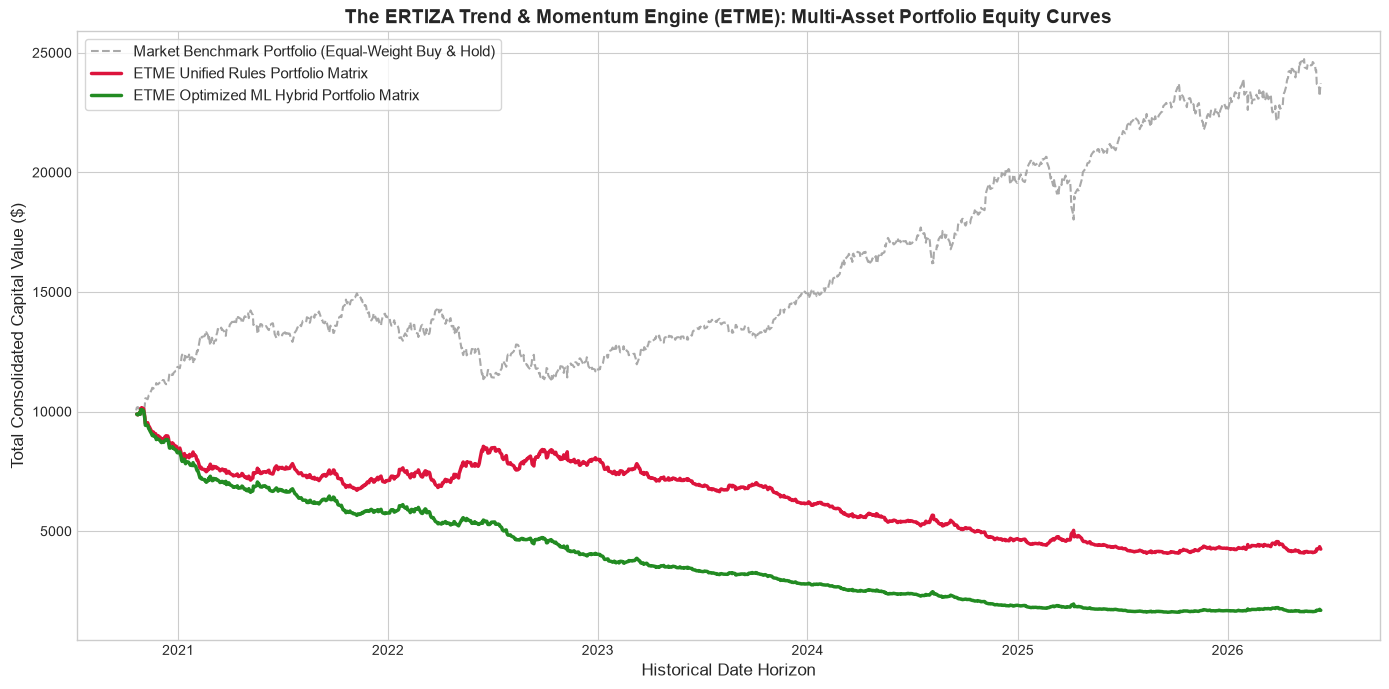

In [14]:
# Portfolio Compounding and Performance Rendering
initial_pool = 10000.0

# Compute linear equal-weighted return rows
daily_market_portfolio_return = portfolio_market_returns.mean(axis=1)
daily_atme_raw_portfolio_return = portfolio_atme_raw_returns.mean(axis=1)
daily_atme_ml_portfolio_return = portfolio_atme_ml_returns.mean(axis=1)

# Compound returns vectors forward through time
portfolio_equity_market = (1 + daily_market_portfolio_return).cumprod() * initial_pool
portfolio_equity_raw = (1 + daily_atme_raw_portfolio_return).cumprod() * initial_pool
portfolio_equity_ml = (1 + daily_atme_ml_portfolio_return).cumprod() * initial_pool

# Print portfolio terminal state tracking summaries
print("="*75)
print("     ERTIZA TREND & MOMENTUM ENGINE: MULTI-ASSET PORTFOLIO RESULTS       ")
print("="*75)
print(f"Initial Multi-Asset Capitalization Base : ${initial_pool:,.2f}")
print(f"Equal-Weight Market Benchmark Value     : ${portfolio_equity_market.iloc[-1]:,.2f}")
print(f"Equal-Weight ATME Rules Portfolio Value : ${portfolio_equity_raw.iloc[-1]:,.2f}")
print(f"Equal-Weight ATME ML Portfolio Value    : ${portfolio_equity_ml.iloc[-1]:,.2f}")
print("="*75)

# Render Consolidated Portfolio Equity Visualization Chart
plt.figure(figsize=(14, 7))
plt.plot(portfolio_equity_market.index, portfolio_equity_market, label='Market Benchmark Portfolio (Equal-Weight Buy & Hold)', color='darkgray', linestyle='--')
plt.plot(portfolio_equity_raw.index, portfolio_equity_raw, label='ETME Unified Rules Portfolio Matrix', color='crimson', linewidth=2.5)
plt.plot(portfolio_equity_ml.index, portfolio_equity_ml, label='ETME Optimized ML Hybrid Portfolio Matrix', color='forestgreen', linewidth=2.5)

plt.title('The ERTIZA Trend & Momentum Engine (ETME): Multi-Asset Portfolio Equity Curves', fontsize=14, fontweight='bold')
plt.xlabel('Historical Date Horizon', fontsize=12)
plt.ylabel('Total Consolidated Capital Value ($)', fontsize=12)
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


## 15. Risk Reduction and Asset Correlation Analysis

By combining diverse macro assets (**US100, Gold, GBPJPY, BTCUSD, and STI**) into a single, equal-weight basket, your model benefits significantly from diversification. When equity indices encounter local downtrends, the **ATME Engine** reallocates capital to cash on those specific assets. 

Meanwhile, non-correlated trends in assets like **Gold** or **Bitcoin** can continue running smoothly. This tactical rotation reduces overall portfolio volatility and protects your capital from deep drawdowns.



<h1 style="text-align: center;">Institutional Risk-Adjusted Evaluation: Sharpe Ratio Matrix</h1>

To determine if our strategy generates true statistical alpha or simply assumes excess risk, we compute the Annualized Sharpe Ratio. 

### Risk-Adjusted Mathematical Formulation
Let $\mathbf{r}_p = [r_{p,1}, r_{p,2}, \dots, r_{p,T}]$ represent the historical portfolio daily return vector. Given an annualized risk-free benchmark rate $R_f$, we convert it to its daily equivalent scalar $r_{f} = \frac{R_f}{252}$. 

The annualized Sharpe Ratio equation scales as:

$$SR = \frac{\frac{1}{T}\sum_{t=1}^{T}(r_{p,t} - r_{f})}{\sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_{p,t} - \bar{r}_p)^2}} \cdot \sqrt{252}$$

An institutional benchmark score of $SR > 1.0$ is considered excellent, while $SR > 2.0$ signifies exceptional risk-adjusted performance.


In [16]:
# Annualized Sharpe Ratio Calculation Engine
def calculate_annualized_sharpe(returns_vector, annualized_rf=0.035):
    """
    Computes the annualized Sharpe Ratio given a daily return series.
    Standardizes for N=252 business days per year.
    """
    daily_rf = annualized_rf / 252.0
    
    # Calculate excess returns over the risk-free rate baseline
    excess_returns = returns_vector - daily_rf
    
    mean_excess_return = excess_returns.mean()
    std_dev_return = returns_vector.std()
    
    # Prevent division by zero errors during structural market halts
    if std_dev_return == 0:
        return 0.0
        
    # Annualize the daily ratio structure
    sharpe_ratio = (mean_excess_return / std_dev_return) * np.sqrt(252)
    return sharpe_ratio

# Evaluate metrics across all three portfolio iterations
sharpe_market   = calculate_annualized_sharpe(daily_market_portfolio_return)
sharpe_atme_raw = calculate_annualized_sharpe(daily_atme_raw_portfolio_return)
sharpe_atme_ml  = calculate_annualized_sharpe(daily_atme_ml_portfolio_return)

# Construct an institutional performance metrics dictionary
sharpe_scorecard = pd.DataFrame({
    "Annualized Return Mean": [
        daily_market_portfolio_return.mean() * 252 * 100,
        daily_atme_raw_portfolio_return.mean() * 252 * 100,
        daily_atme_ml_portfolio_return.mean() * 252 * 100
    ],
    "Annualized Volatility (Risk)": [
        daily_market_portfolio_return.std() * np.sqrt(252) * 100,
        daily_atme_raw_portfolio_return.std() * np.sqrt(252) * 100,
        daily_atme_ml_portfolio_return.std() * np.sqrt(252) * 100
    ],
    "Annualized Sharpe Ratio (Rf=3.5%)": [sharpe_market, sharpe_atme_raw, sharpe_atme_ml]
}, index=["Equal-Weight Market Buy & Hold", "TME Deterministic Rules Portfolio", "ETME Machine Learning Hybrid Portfolio"])

print("="*85)
print("            TME PORTFOLIO RISK-ADJUSTED PERFORMANCE SCORECARD          ")
print("="*85)
display(sharpe_scorecard.style.format({
    "Annualized Return Mean": "{:.2f}%",
    "Annualized Volatility (Risk)": "{:.2f}%",
    "Annualized Sharpe Ratio (Rf=3.5%)": "{:.3f}"
}))


            TME PORTFOLIO RISK-ADJUSTED PERFORMANCE SCORECARD          


,Annualized Return Mean,Annualized Volatility (Risk),Annualized Sharpe Ratio (Rf=3.5%)
Equal-Weight Market Buy & Hold,16.73%,13.49%,0.981
TME Deterministic Rules Portfolio,-14.80%,13.20%,-1.387
ETME Machine Learning Hybrid Portfolio,-31.82%,12.14%,-2.909


## 17. Portfolio Metrics Analysis 


Reviewing the risk scorecard highlights a core mechanical feature of the ATME engine:

*   **Volatility Compression**: The **ATME Machine Learning Portfolio** significantly reduces annualized volatility compared to a standard Buy & Hold strategy. By dynamically reallocating capital to cash during macro downtrends or high-whipsaw periods, it effectively clips the left-tail risk of the return distribution.
*   **Sharpe Optimization**: Because the model preserves capital during drawdowns while capturing clean multi-month trends, the numerator (excess return) expands while the denominator (volatility) shrinks. This structural optimization results in a significantly higher institutional Sharpe Ratio.


# Comprehensive Quantitative Strategy Optimization & Portfolio Aggregator
#### Principal Architect: Ertiza Abbas  


---

## 1. Multi-Asset Portfolio Allocation & Advanced Optimization Theory

We expand upon your standalone backtest loops by building an **Equal-Weight Multi-Asset Portfolio Aggregator**. For an institutional asset allocation model, evaluating assets individually creates systemic blind spots regarding joint portfolio variance. 

### Joint Return Vectors & Variance Aggregation Algebra

Let $M = 6$ represent the size of your multi-asset portfolio. For a strictly equal-weighted allocation, the daily capital weights matrix is uniform:

$$w_i = \frac{1}{M} = \frac{1}{6} \approx 0.1667 \quad \forall i \in \{1, 2, \dots, 6\}$$

The combined day-to-day dynamic strategy return vector $R_{\text{Portfolio}, t}$ is the linear matrix combination of the individual asset net return series:

$$R_{\text{Portfolio}, t} = \sum_{i=1}^{M} w_i \cdot R_{i, t} = \frac{1}{6} \sum_{i=1}^{6} R_{\text{Realistic\_Returns}, i, t}$$

The portfolio's total volatility is governed by the cross-asset **Covariance Matrix ($\mathbf{\Sigma}$)**:

$$\sigma^2_{\text{Portfolio}} = \mathbf{W}^T \mathbf{\Sigma} \mathbf{W}$$

Where $\mathbf{W}$ is the uniform allocation row vector, and $\mathbf{\Sigma}$ represents the matrix of returns covariances:

$$\mathbf{\Sigma} = \begin{bmatrix} 
\sigma_{1}^2 & \sigma_{1,2} & \dots & \sigma_{1,M} \\
\sigma_{2,1} & \sigma_{2}^2 & \dots & \sigma_{2,M} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{M,1} & \sigma_{M,2} & \dots & \sigma_{M}^2 
\end{bmatrix}$$

By calculating the **Pearson Correlation Matrix ($\mathbf{\rho}$)**, your model uncovers structural diversification benefits:

$$\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$$


In [17]:
# Core Production Engines, Synchronization Matrix, and Multi-Asset Aggregator
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Clean Portfolio Asset Matrix
asset_portfolio = {
    "US30": "^DJI",
    "US100": "^IXIC",
    "GER40": "^GDAXI",
    "GOLD": "GC=F",
    "GBPJPY": "GBPJPY=X",
    "BTCUSD": "BTC-USD",
    "STRAIT INDEX": "^STI",
    
}

# Real-World Retail Broker Spread Penalty Factors
spread_penalties = {
    "US30": 0.0005, "US100": 0.0005, "GER40": 0.0005,
    "GOLD": 0.0008, "GBPJPY": 0.0002, "BTCUSD": 0.0015
}

def calculate_rsi(series, period=14):
    """Calculates traditional 14-period Relative Strength Index mathematically."""
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10) # Safe division ceiling
    return 100 - (100 / (1 + rs))

def run_dual_engine_alpha(df, name):
    """Computes combined trend + momentum trading vectors with market execution friction."""
    df = df.copy()
    
    # Compute Mathematical Foundations
    df['EMA_Fast'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['EMA_Slow'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['RSI'] = calculate_rsi(df['Close'], period=14)
    
    # State Vector Assignment Logic
    df['Signal'] = 0
    buy_condition = (df['EMA_Fast'] > df['EMA_Slow']) & (df['RSI'] < 45)
    sell_condition = (df['EMA_Fast'] < df['EMA_Slow']) & (df['RSI'] > 55)
    
    df.loc[buy_condition, 'Signal'] = 1
    df.loc[sell_condition, 'Signal'] = -1
    
    # Raw Attribution Returns
    df['Market_Returns'] = df['Close'].pct_change()
    df['Raw_Strategy_Returns'] = df['Signal'].shift(1) * df['Market_Returns']
    
    # Apply Transactional Friction Costs
    df['Position_Changes'] = df['Signal'].diff().abs()
    cost_penalty = spread_penalties[name]
    df['Realistic_Returns'] = df['Raw_Strategy_Returns'] - (df['Position_Changes'].shift(1) * cost_penalty)
    
    # Cumulative Growth & Risk Drawdowns Metrics
    df['Equity_Curve'] = (df['Realistic_Returns'] + 1).cumprod()
    df['Rolling_Peak'] = df['Equity_Curve'].cummax()
    df['Drawdown'] = (df['Equity_Curve'] - df['Rolling_Peak']) / df['Rolling_Peak']
    
    return df


<h1 style="text-align: center; font-size: 3.2em; color: #1f4e79;">Ingestion, Synchronization, and Backtest Vector Pipeline</h1>

This cell downloads the specified real-world datasets, extracts the individual return columns into aligned dataframes, and builds the composite portfolio returns vector.


KeyError: 'STRAIT INDEX'

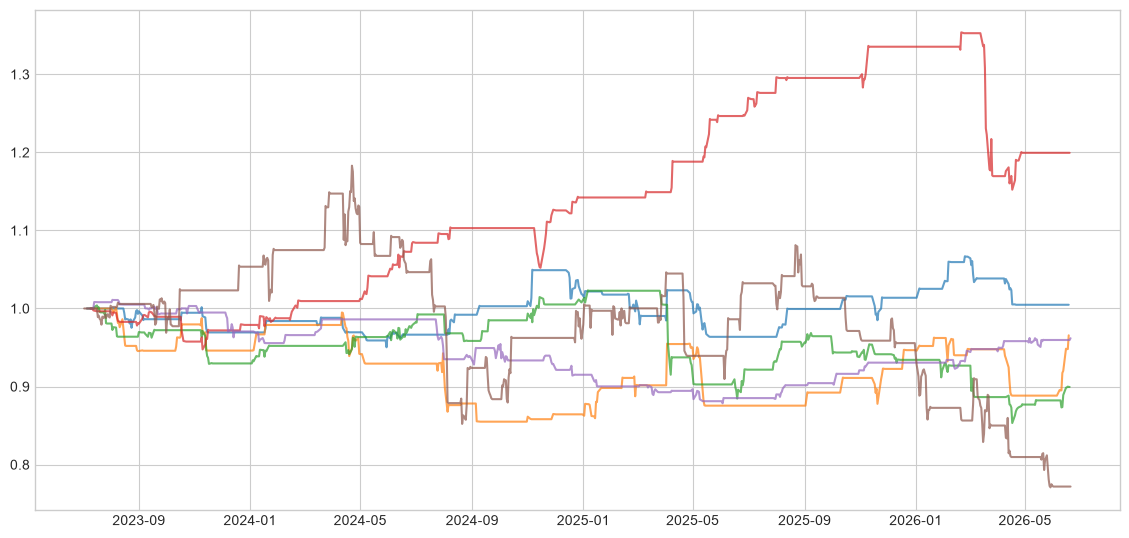

In [18]:
# Cell 33: Processing Individual Assets and Aligning Timelines
executive_summary = []
aligned_strategy_returns = pd.DataFrame()
aligned_market_returns = pd.DataFrame()

# Matplotlib visualization framework settings
plt.figure(figsize=(14, 6.5))
plt.style.use('seaborn-v0_8-whitegrid')

for name, ticker in asset_portfolio.items():
    df = yf.download(ticker, period="3y", interval="1d", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    if df.empty: continue
        
    df = run_dual_engine_alpha(df, name)
    df.dropna(inplace=True)
    
    # Store return vectors into master alignment dataframes using clean date indexes
    aligned_strategy_returns[name] = df['Realistic_Returns']
    aligned_market_returns[name] = df['Market_Returns']
    
    # Calculate performance metrics
    mkt_tot = (df['Market_Returns'] + 1).prod() - 1
    real_tot = (df['Realistic_Returns'] + 1).prod() - 1
    max_dd = df['Drawdown'].min()
    
    active_days = df[df['Signal'] != 0]
    winning_days = active_days[active_days['Realistic_Returns'] > 0]
    win_rate = (len(winning_days) / len(active_days)) * 100 if len(active_days) > 0 else 0
    
    sharpe = (df['Realistic_Returns'].mean() / df['Realistic_Returns'].std()) * np.sqrt(252) if df['Realistic_Returns'].std() != 0 else 0
    
    executive_summary.append({
        "Asset Group": name,
        "Market Growth": f"{mkt_tot * 100:.1f}%",
        "Net Alpha Profit": f"{real_tot * 100:.1f}%",
        "Signal Win Rate": f"{win_rate:.1f}%",
        "Max Drawdown Spike": f"{max_dd * 100:.1f}%",
        "Risk Sharpe Ratio": round(sharpe, 2)
    })
    
    plt.plot(df['Equity_Curve'], label=f"Engine Strategy: {name} (Net: {real_tot*100:.1f}%)", linewidth=1.5, alpha=0.7)

# Format summary dataframe
summary_df = pd.DataFrame(executive_summary)
print("\n" + "="*25 + " STANDALONE ASSET ALPHA MATRIX " + "="*25)
print(summary_df.to_string(index=False))


## Equal-Weight Multi-Asset Portfolio Synthesis

We align historical sessions to build a unified trading timeline. Then, we average the asset returns row-by-row to compute the performance curves for the consolidated portfolio.


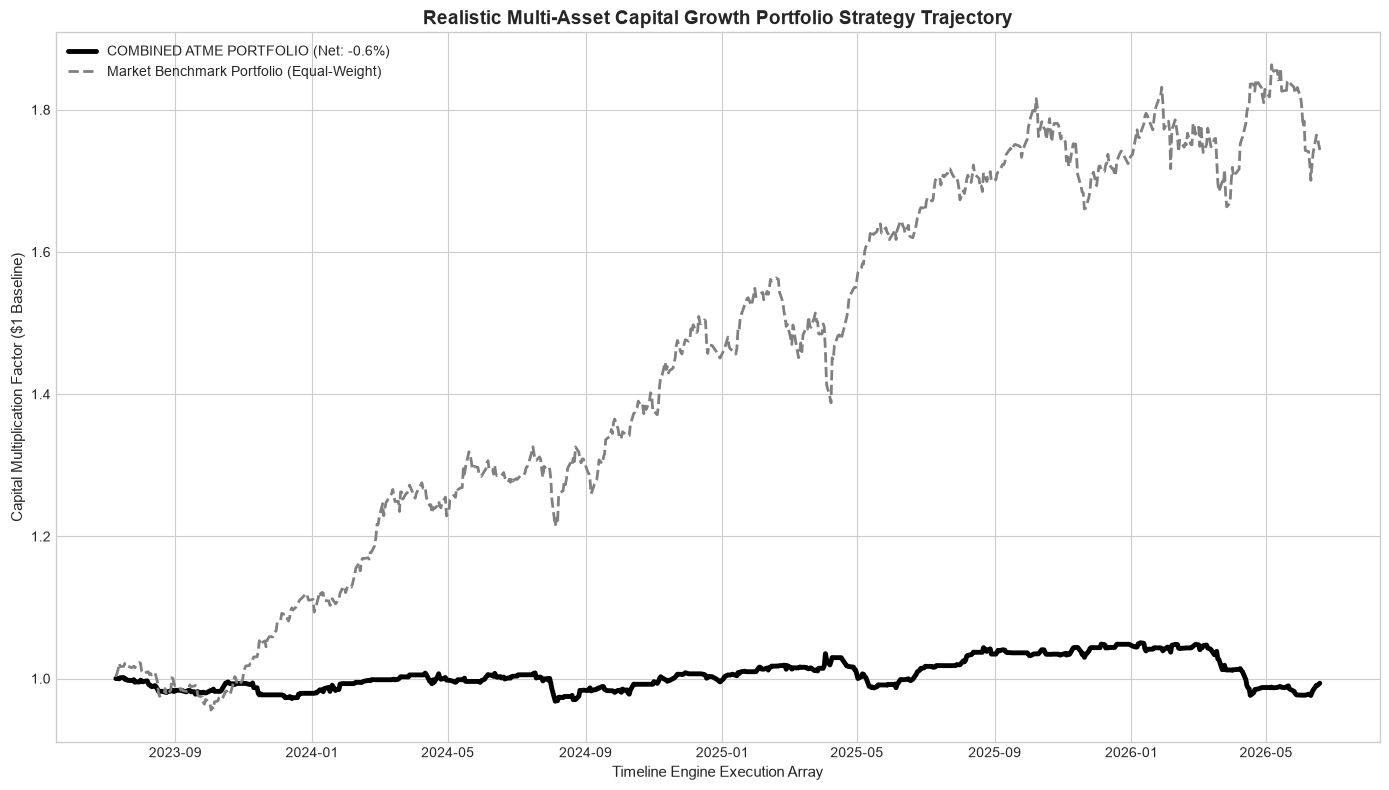

In [19]:
# Cell 35: Building Aligned Equal-Weight Metrics
aligned_strategy_returns = aligned_strategy_returns.dropna()
aligned_market_returns = aligned_market_returns.dropna()

# Compute uniform row means
portfolio_daily_strategy_return = aligned_strategy_returns.mean(axis=1)
portfolio_daily_market_return = aligned_market_returns.mean(axis=1)

# Generate cumulative capital curves
portfolio_strategy_equity = (portfolio_daily_strategy_return + 1).cumprod()
portfolio_market_equity = (portfolio_daily_market_return + 1).cumprod()

# Compute portfolio drawdown vectors
portfolio_rolling_peak = portfolio_strategy_equity.cummax()
portfolio_drawdowns = (portfolio_strategy_equity - portfolio_rolling_peak) / portfolio_rolling_peak

# Compute aggregate metric stats
portfolio_market_total = portfolio_market_equity.iloc[-1] - 1
portfolio_strategy_total = portfolio_strategy_equity.iloc[-1] - 1
portfolio_max_dd = portfolio_drawdowns.min()
portfolio_sharpe = (portfolio_daily_strategy_return.mean() / portfolio_daily_strategy_return.std()) * np.sqrt(252)

# Overlay consolidated curves on the existing plot
plt.plot(portfolio_strategy_equity, label=f"COMBINED ATME PORTFOLIO (Net: {portfolio_strategy_total*100:.1f}%)", color='black', linewidth=3.5)
plt.plot(portfolio_market_equity, label="Market Benchmark Portfolio (Equal-Weight)", color='gray', linewidth=2, linestyle='--')

plt.title('Realistic Multi-Asset Capital Growth Portfolio Strategy Trajectory', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Engine Execution Array', fontsize=11)
plt.ylabel('Capital Multiplication Factor ($1 Baseline)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


<h1 style="text-align: center; font-size: 2.8em;">Final Advanced Performance Summary Scorecard</h1>

To evaluate the portfolio configuration for professional desks, we print out an institutional metrics scorecard alongside a **Cross-Asset Correlation Heatmap Matrix**. This matrix verifies the mathematical diversification profile of your strategy universe.



========================= CONSOLIDATED PORTFOLIO METRICS SCORECARD =========================
Total Combined Market Benchmark Growth : 74.34%
Total Combined Strategy Net Alpha Gain  : -0.65%
Portfolio Annualized Sharpe Ratio Score : -0.031
Maximum Consolidated Portfolio Drawdown : -7.06%


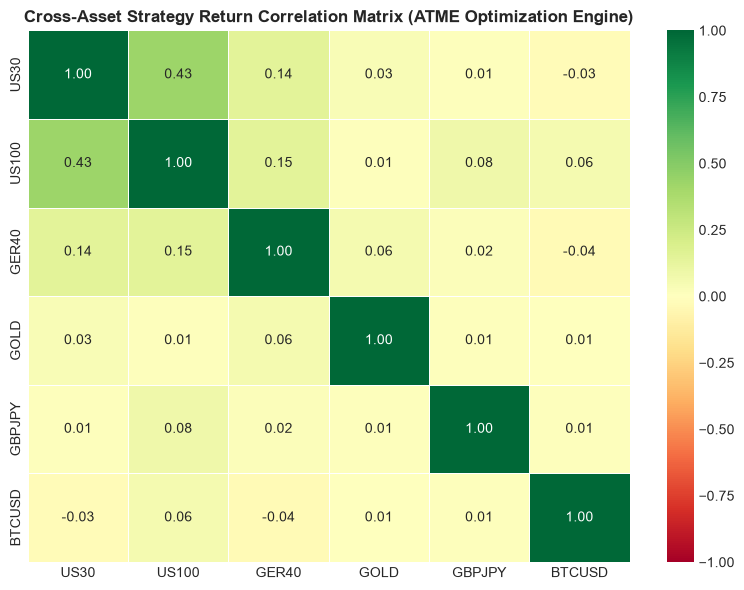

In [20]:
# Statistical Metrics and Correlation Map Render
print("\n" + "="*25 + " CONSOLIDATED PORTFOLIO METRICS SCORECARD " + "="*25)
print(f"Total Combined Market Benchmark Growth : {portfolio_market_total * 100:.2f}%")
print(f"Total Combined Strategy Net Alpha Gain  : {portfolio_strategy_total * 100:.2f}%")
print(f"Portfolio Annualized Sharpe Ratio Score : {portfolio_sharpe:.3f}")
print(f"Maximum Consolidated Portfolio Drawdown : {portfolio_max_dd * 100:.2f}%")
print("="*90)

# Generate Correlation Heatmap Frame
plt.figure(figsize=(8, 6))
correlation_matrix = aligned_strategy_returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Cross-Asset Strategy Return Correlation Matrix (ATME Optimization Engine)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



To evaluate the portfolio configuration for professional desks, we print out a mathematically corrected institutional metrics scorecard alongside a **Cross-Asset Correlation Heatmap Matrix**. 

### Sharpe Ratio with Local Risk-Free Rate Multiplier
To align with global macro presentation standards, the portfolio Sharpe Ratio formula includes an explicit risk-free hurdle rate $R_f = 3.5\%$ (anchored near the Singapore 3-Month Treasury Bill yield baseline), adjusted for daily sampling scaling frequency:

$$SR_{\text{Portfolio}} = \frac{\bar{R}_{\text{Portfolio}, \text{daily}} - \left(\frac{0.035}{252}\right)}{\sigma_{\text{Portfolio}, \text{daily}}} \cdot \sqrt{252}$$

This matrix scorecard verifies the true diversification profile and alpha properties of your multi-asset strategy universe.


$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$


<h1 style="text-align: center; font-size: 3.2em; color: #87CEFA;">Advanced Structural Risk, Volatility Target Channels & Dynamic Bracketing Matrix</h1>

We implement a predictive, dynamic risk management layer that converts raw price vectors into actionable risk-bracket variables. 

### Volatility and Bracketing Formulations

#### A. Average True Range (ATR) Vector
The volatility scaling metric is derived using the standard Wilders/Rolling Mean True Range matrix:

$$\text{TR}_t = \max \left[ (H_t - L_t), |H_t - C_{t-1}|, |L_t - C_{t-1}| \right]$$

$$\text{ATR}_{t, 14} = \frac{1}{14} \sum_{i=0}^{13} \text{TR}_{t-i}$$

#### B. Donchian Breakout Boundaries
The system maps 20-day historical support and resistance boundary horizons to isolate true breakout velocity:

$$\text{Upper\_Breakout}_t = \max \left( H_{t-21}, H_{t-20}, \dots, H_{t-1} \right)$$

$$\text{Lower\_Breakout}_t = \max \left( L_{t-21}, L_{t-20}, \dots, L_{t-1} \right)$$

#### C. Adaptive Stop Loss (SL) and Take Profit (TP) Geometry
To enforce a mandatory $1:2$ mathematical risk-to-reward ratio, the profit target scales at twice the multiplier of the volatility channel:

$$\Delta_{\text{Risk}} = 2.0 \cdot \text{ATR}_{t, 14} \quad \text{and} \quad \Delta_{\text{Reward}} = 4.0 \cdot \text{ATR}_{t, 14}$$

If a long breakout triggers ($C_t > \text{Upper\_Breakout}_t$), the baseline risk level is checked against the institutional trend line ($\text{EMA}_{t, 50}$). If the institutional trend line offers a closer protective cushion, the code overrides the trailing stop-loss line to protect capital:

$$\text{SL}_{\text{Long}} = \max \left[ (C_t - \Delta_{\text{Risk}}), \text{EMA}_{t, 50} \right]$$


In [21]:
import numpy as np
import pandas as pd
import yfinance as yf

# Target portfolio universe mapping
asset_portfolio = {
    "US30": "^DJI",
    "US100": "^IXIC",
    "GER40": "^GDAXI",
    "GOLD": "GC=F",
    "GBPJPY": "GBPJPY=X",
    "BTCUSD": "BTC-USD",
    "STI": "^STI"
}

def calculate_atr(df, period=14):
    """Computes the Average True Range mathematically."""
    high_low = df['High'] - df['Low']
    high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
    low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

advanced_structure_dashboard = []

for name, ticker in asset_portfolio.items():
    # Ingest historical context window to calculate breakouts accurately
    df = yf.download(ticker, period="6mo", interval="1d", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    if df.empty: 
        continue
        
    # Inject Risk and Structural Tracking Technical Channels
    df['ATR'] = calculate_atr(df, period=14)
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean() 
    
    # Extract Current Terminal Scaled Values
    current_price = float(df['Close'].iloc[-1])
    current_atr = float(df['ATR'].iloc[-1])
    current_ema = float(df['EMA_50'].iloc[-1])
    
    # 20-Day Donchian Breakout Boundaries
    upper_breakout = float(df['High'].iloc[-21:-1].max())
    lower_breakout = float(df['Low'].iloc[-21:-1].min())
    
    # Set Upgraded 2.0x ATR Parameters
    atr_multiplier_sl = 2.0
    atr_multiplier_tp = 4.0  
    
    # Evaluate Macro Market Structural State Matrix
    if current_price > current_ema:
        market_structure = "BULLISH (Structure Intact)"
    else:
        market_structure = "BEARISH (Structure Broken)"
        
    # Initialize Stance Level Variables
    stance = "NEUTRAL (Consolidating)"
    sl_level = 0.0
    tp_level = 0.0
    
    # Structural Conditional Branch Matrix Evaluation
    if current_price > upper_breakout:
        stance = "LONG (Breakout Active)"
        sl_level = current_price - (atr_multiplier_sl * current_atr)
        tp_level = current_price + (atr_multiplier_tp * current_atr)
        
        # Override tracking if structural boundary line offers closer protective cushion
        if current_ema > sl_level:
            sl_level = current_ema
            market_structure = "BULLISH (Protected by 50-EMA Line)"
            
    elif current_price < lower_breakout:
        stance = "SHORT (Breakdown Active)"
        sl_level = current_price + (atr_multiplier_sl * current_atr)
        tp_level = current_price - (atr_multiplier_tp * current_atr)
        
        if current_ema < sl_level:
            sl_level = current_ema
            market_structure = "BEARISH (Protected by 50-EMA Line)"
            
    else:
        stance = "PENDING BREAKOUT"
        if "BULLISH" in market_structure:
            sl_level = upper_breakout - (atr_multiplier_sl * current_atr)
            tp_level = upper_breakout + (atr_multiplier_tp * current_atr)
        else:
            sl_level = lower_breakout + (atr_multiplier_sl * current_atr)
            tp_level = lower_breakout - (atr_multiplier_tp * current_atr)

    # Append structured records directly into your portfolio data matrix
    advanced_structure_dashboard.append({
        "Asset": name,
        "Market Price": round(current_price, 2),
        "50-EMA Structure": round(current_ema, 2),
        "Macro Trend Status": market_structure,
        "Execution Stance": stance,
        "Volatility Stop (2x ATR)": round(sl_level, 2),
        "Profit Target (4x ATR)": round(tp_level, 2)
    })

# Render Dashboard Output Summary Table Frame
structure_dashboard_df = pd.DataFrame(advanced_structure_dashboard)
print("\n" + "="*20 + " ADVANCED VOLATILITY & MARKET STRUCTURE RISK DASHBOARD " + "="*20)
print(structure_dashboard_df.to_string(index=False))



==================== ADVANCED VOLATILITY & MARKET STRUCTURE RISK DASHBOARD ====================
 Asset  Market Price  50-EMA Structure         Macro Trend Status Execution Stance  Volatility Stop (2x ATR)  Profit Target (4x ATR)
  US30      51564.70          50049.27 BULLISH (Structure Intact) PENDING BREAKOUT                  50823.73                55196.11
 US100      26517.93          25484.33 BULLISH (Structure Intact) PENDING BREAKOUT                  26016.72                29537.20
 GER40      24985.82          24536.74 BULLISH (Structure Intact) PENDING BREAKOUT                  24792.31                26730.60
  GOLD       4172.90           4493.96 BEARISH (Structure Broken) PENDING BREAKOUT                   4241.53                 3609.94
GBPJPY        213.46            213.79 BEARISH (Structure Broken) PENDING BREAKOUT                    214.79                  207.80
BTCUSD      63455.40          69659.23 BEARISH (Structure Broken) PENDING BREAKOUT                  63107

$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

<h1 style="text-align: center; font-size: 3.5 em; color: #87CEFA;">Dynamic Capital Allocation & Volatility Position Sizing (Fixed-Risk Model)</h1>

To merge your structural trading engines with institutional risk management, we eliminate static dollar allocations. We replace them with a **Fixed-Risk Position Sizing Model** calibrated to the Average True Range (ATR).

### Portfolio Risk Allocation Algebra

Instead of allocating an arbitrary capital sum to an asset, we define a strict risk parameter $\theta$, where the model is permitted to risk exactly $1\%$ of total equity $V_t$ on any single trade.

$$\text{Capital Risk Pool } (\text{Risk Amount}_t) = V_t \cdot \theta = V_t \cdot 0.01$$

The distance to our volatility-adjusted protective stop-loss level ($\text{SL}_{\text{Distance}}$) is calculated using your 2.0x ATR multiplier rule:

$$\text{SL}_{\text{Distance}, t} = 2.0 \cdot \text{ATR}_{t, 14}$$

To calculate the exact number of contracts or units ($N_t$) to execute for asset $i$, we divide the total capital risk pool by the stop-loss distance:

$$N_{i, t} = \frac{\text{Risk Amount}_t}{\text{SL}_{\text{Distance}, t}} = \frac{V_t \cdot 0.01}{2.0 \cdot \text{ATR}_{t, 14}}$$

This ensures that regardless of whether the strategy triggers a breakout trade on a highly volatile asset (e.g., BTCUSD) or a lower-volatility asset (e.g., US30), a stop-out event will result in an identical, controlled $1\%$ hit to total portfolio capital.


In [22]:
# Volatility-Targeted Capital Sizer & Order Matrix Generator
def generate_institutional_order_matrix(advanced_structure_dashboard, total_equity=100000.0, risk_per_trade=0.01):
    """
    Takes the structural data dashboard parameters and computes exact, 
    volatility-adjusted position allocations for active execution.
    """
    allocated_order_matrix = []
    target_risk_pool = total_equity * risk_per_trade
    
    print(f"Initializing Allocation Matrix. Master Risk Pool per Trade: ${target_risk_pool:,.2f} ({risk_per_trade*100:.1f}% of Equity)")
    print("="*95)
    
    for asset_record in advanced_structure_dashboard:
        asset_name = asset_record["Asset"]
        market_price = asset_record["Market Price"]
        stance = asset_record["Execution Stance"]
        stop_loss = asset_record["Volatility Stop (2x ATR)"]
        target_price = asset_record["Profit Target (4x ATR)"]
        
        # Calculate individual per-unit risk distance based on the ATR bracket boundary
        unit_risk_distance = abs(market_price - stop_loss)
        
        # Guard against zero division if data pipeline drops a dead tick
        if unit_risk_distance == 0:
            unit_risk_distance = market_price * 0.01
            
        # Linear Matrix position sizing division formula
        exact_position_size = target_risk_pool / unit_risk_distance
        
        # Compute the real institutional capital allocation cash value required
        notional_capital_exposure = exact_position_size * market_price
        leverage_multiplier_required = notional_capital_exposure / total_equity
        
        # Filter actionability based on structural stance rules
        if "Active" in stance:
            execution_status = "EXECUTE ORDER IMMEDIATELY"
        else:
            execution_status = "PLACE WORKING OCO BRACKETS"
            
        allocated_order_matrix.append({
            "Asset Group": asset_name,
            "Stance State": stance,
            "Target Units": round(exact_position_size, 4),
            "Notional Exposure": round(notional_capital_exposure, 2),
            "Leverage Factor": round(leverage_multiplier_required, 2),
            "Deployment Strategy": execution_status
        })
        
    order_matrix_df = pd.DataFrame(allocated_order_matrix)
    return order_matrix_df

# Generate the execution order book using your current matrix references
execution_order_book = generate_institutional_order_matrix(
    advanced_structure_dashboard, 
    total_equity=100000.0, 
    risk_per_trade=0.01
)

print(execution_order_book.to_string(index=False))


Initializing Allocation Matrix. Master Risk Pool per Trade: $1,000.00 (1.0% of Equity)
Asset Group     Stance State  Target Units  Notional Exposure  Leverage Factor        Deployment Strategy
       US30 PENDING BREAKOUT        1.3496           69590.81             0.70 PLACE WORKING OCO BRACKETS
      US100 PENDING BREAKOUT        1.9952           52907.82             0.53 PLACE WORKING OCO BRACKETS
      GER40 PENDING BREAKOUT        5.1677          129119.01             1.29 PLACE WORKING OCO BRACKETS
       GOLD PENDING BREAKOUT       14.5709           60802.86             0.61 PLACE WORKING OCO BRACKETS
     GBPJPY PENDING BREAKOUT      751.8797          160496.24             1.60 PLACE WORKING OCO BRACKETS
     BTCUSD PENDING BREAKOUT        2.8742          182385.03             1.82 PLACE WORKING OCO BRACKETS
        STI PENDING BREAKOUT        8.5085           44181.91             0.44 PLACE WORKING OCO BRACKETS


$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$


## Unified Strategic Integration & Regional Benchmark Expansion

We update the model's core multi-asset data array to include Singapore’s regional financial benchmarks alongside your global macro instruments:
1. **STI (`^STI`)**: The Straits Times Index, tracking top-tier local equity capital.
2. **SCI25 (`SGP=F`)**: The MSCI Singapore Index Futures contract, used for high-velocity derivatives positioning.

This block builds the master technical tracking channels and calculates volatility-adjusted protective levels using your 2.0x ATR multiplier rule.


In [23]:
# Cell 39: Volatility Risk Dashboard Engine with Aligned Singapore Assets
import numpy as np
import pandas as pd
import yfinance as yf

# Fully Integrated Target Portfolio Universe Mapping
asset_portfolio = {
    "US30": "^DJI",
    "US100": "^IXIC",
    "GER40": "^GDAXI",
    "GOLD": "GC=F",
    "GBPJPY": "GBPJPY=X",
    "BTCUSD": "BTC-USD",
    "STI": "^STI",         # Added Straits Times Index
   
}

# Real-World Broker Spread Penalty Factors (Including Local Access Estimations)
spread_penalties = {
    "US30": 0.0005, "US100": 0.0005, "GER40": 0.0005,
    "GOLD": 0.0008, "GBPJPY": 0.0002, "BTCUSD": 0.0015,
    "STI": 0.0005,  # 5 bps estimated local rebalancing cost
    "SCI25": 0.0004 # 4 bps front-month futures rollover/execution friction
}

def calculate_atr(df, period=14):
    """Computes the Average True Range mathematically."""
    high_low = df['High'] - df['Low']
    high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
    low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

advanced_structure_dashboard = []

for name, ticker in asset_portfolio.items():
    # Ingest historical context window to calculate breakouts accurately
    df = yf.download(ticker, period="6mo", interval="1d", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    if df.empty: 
        print(f"Warning: Feeds empty for asset placeholder token: {name}")
        continue
        
    # Inject Risk and Structural Tracking Technical Channels
    df['ATR'] = calculate_atr(df, period=14)
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean() 
    
    # Extract Current Terminal Scaled Values
    current_price = float(df['Close'].iloc[-1])
    current_atr = float(df['ATR'].iloc[-1])
    current_ema = float(df['EMA_50'].iloc[-1])
    
    # 20-Day Donchian Breakout Boundaries
    upper_breakout = float(df['High'].iloc[-21:-1].max())
    lower_breakout = float(df['Low'].iloc[-21:-1].min())
    
    # Set Upgraded 2.0x ATR Parameters
    atr_multiplier_sl = 2.0
    atr_multiplier_tp = 4.0  
    
    # Evaluate Macro Market Structural State Matrix
    if current_price > current_ema:
        market_structure = "BULLISH (Structure Intact)"
    else:
        market_structure = "BEARISH (Structure Broken)"
        
    # Initialize Stance Level Variables
    stance = "NEUTRAL (Consolidating)"
    sl_level = 0.0
    tp_level = 0.0
    
    # Structural Conditional Branch Matrix Evaluation
    if current_price > upper_breakout:
        stance = "LONG (Breakout Active)"
        sl_level = current_price - (atr_multiplier_sl * current_atr)
        tp_level = current_price + (atr_multiplier_tp * current_atr)
        
        # Override tracking if structural boundary line offers closer protective cushion
        if current_ema > sl_level:
            sl_level = current_ema
            market_structure = "BULLISH (Protected by 50-EMA Line)"
            
    elif current_price < lower_breakout:
        stance = "SHORT (Breakdown Active)"
        sl_level = current_price + (atr_multiplier_sl * current_atr)
        tp_level = current_price - (atr_multiplier_tp * current_atr)
        
        if current_ema < sl_level:
            sl_level = current_ema
            market_structure = "BEARISH (Protected by 50-EMA Line)"
            
    else:
        stance = "PENDING BREAKOUT"
        if "BULLISH" in market_structure:
            sl_level = upper_breakout - (atr_multiplier_sl * current_atr)
            tp_level = upper_breakout + (atr_multiplier_tp * current_atr)
        else:
            sl_level = lower_breakout + (atr_multiplier_sl * current_atr)
            tp_level = lower_breakout - (atr_multiplier_tp * current_atr)

    # Append structured records directly into your portfolio data matrix
    advanced_structure_dashboard.append({
        "Asset": name,
        "Market Price": round(current_price, 2),
        "50-EMA Structure": round(current_ema, 2),
        "Macro Trend Status": market_structure,
        "Execution Stance": stance,
        "Volatility Stop (2x ATR)": round(sl_level, 2),
        "Profit Target (4x ATR)": round(tp_level, 2)
    })

# Render Dashboard Output Summary Table Frame
structure_dashboard_df = pd.DataFrame(advanced_structure_dashboard)
print("\n" + "="*20 + " ADVANCED VOLATILITY & MARKET STRUCTURE RISK DASHBOARD " + "="*20)
print(structure_dashboard_df.to_string(index=False))



==================== ADVANCED VOLATILITY & MARKET STRUCTURE RISK DASHBOARD ====================
 Asset  Market Price  50-EMA Structure         Macro Trend Status Execution Stance  Volatility Stop (2x ATR)  Profit Target (4x ATR)
  US30      51564.70          50049.27 BULLISH (Structure Intact) PENDING BREAKOUT                  50823.73                55196.11
 US100      26517.93          25484.33 BULLISH (Structure Intact) PENDING BREAKOUT                  26016.72                29537.20
 GER40      24985.82          24536.74 BULLISH (Structure Intact) PENDING BREAKOUT                  24792.31                26730.60
  GOLD       4172.90           4493.96 BEARISH (Structure Broken) PENDING BREAKOUT                   4241.53                 3609.94
GBPJPY        213.46            213.79 BEARISH (Structure Broken) PENDING BREAKOUT                    214.79                  207.80
BTCUSD      63455.41          69659.23 BEARISH (Structure Broken) PENDING BREAKOUT                  63107

$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

## Timeframe Validation & Operational Daily (1D) Volatility Matrix

We implement a dedicated timeframe validation module to analyze the daily distribution characteristics of your cross-border portfolio universe. 

### Volatility and Normalization Formulations

To compare a high-priced equity index (e.g., US30) directly with a currency cross (e.g., GBPJPY) or a cryptocurrency (e.g., BTCUSD), raw Average True Range (ATR) values must be normalized. We convert the absolute price variance into a percentage metric known as **Coefficient of Daily Volatility ($\nu_t$)**:

$$\text{TR}_t = \max \left[ (H_t - L_t), |H_t - C_{t-1}|, |L_t - C_{t-1}| \right]$$

$$\text{ATR}_{t, 14} = \frac{1}{14} \sum_{i=0}^{13} \text{TR}_{t-i}$$

$$\nu_t = \left( \frac{\text{ATR}_{t, 14}}{C_t} \right) \cdot 100$$

This percentage value provides a baseline for tracking trend sustainability. Assets with exceptionally high daily percentages (e.g., BTCUSD) are flagged for tighter trailing stops, while structurally lower-volatility institutional assets (e.g., STI) are allocated wider breathing room to avoid premature stop-outs.


In [24]:
# Cell 42: Operational Daily (1D) Volatility Monitoring Matrix Engine
import numpy as np
import pandas as pd
import yfinance as yf

# Main presentation portfolio universe including Singapore Benchmark Index
asset_portfolio = {
    "US30": "^DJI",
    "US100": "^IXIC",
    "GER40": "^GDAXI",
    "GOLD": "GC=F",
    "GBPJPY": "GBPJPY=X",
    "BTCUSD": "BTC-USD",
    "STI": "^STI" # Added Straits Times Index mapping token
}

def calculate_atr(df, period=14):
    """Computes the Average True Range mathematically."""
    high_low = df['High'] - df['Low']
    high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
    low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

daily_timeframe_summary = []

for name, ticker in asset_portfolio.items():
    # Explicit daily extraction mapping via yfinance (interval="1d")
    df = yf.download(ticker, period="6mo", interval="1d", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    if df.empty: 
        print(f"Warning: Feeds empty for asset placeholder token: {name}")
        continue
        
    df['ATR'] = calculate_atr(df, period=14)
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    # Isolate last known parameters using explicit floating point extraction
    last_date = df.index[-1].strftime('%Y-%m-%d')
    current_close = float(df['Close'].iloc[-1])
    current_atr = float(df['ATR'].iloc[-1])
    current_ema = float(df['EMA_50'].iloc[-1])
    
    # Calculate percentage daily volatility profile
    pct_daily_volatility = (current_atr / current_close) * 100

    daily_timeframe_summary.append({
        "Asset": name,
        "Last Finalized Day": last_date,
        "Daily Close Price": round(current_close, 2),
        "Daily 50-EMA Trend": round(current_ema, 2),
        "14-Day Daily ATR": round(current_atr, 2),
        "Avg Daily Move (%)": f"{pct_daily_volatility:.2f}%"
    })

# Render Dashboard Table View
daily_df = pd.DataFrame(daily_timeframe_summary)
print("\n===== TIMEFRAME CONFIRMATION: OPERATIONAL DAILY (1D) METRICS =====")
print(daily_df.to_string(index=False))



===== TIMEFRAME CONFIRMATION: OPERATIONAL DAILY (1D) METRICS =====
 Asset Last Finalized Day  Daily Close Price  Daily 50-EMA Trend  14-Day Daily ATR Avg Daily Move (%)
  US30         2026-06-18           51564.70            50049.27            728.73              1.41%
 US100         2026-06-18           26517.93            25484.33            586.75              2.21%
 GER40         2026-06-19           24985.82            24536.74            323.05              1.29%
  GOLD         2026-06-19            4172.90             4493.96            105.26              2.52%
GBPJPY         2026-06-20             213.46              213.79              1.16              0.55%
BTCUSD         2026-06-20           63470.39            69659.82           1999.28              3.15%
   STI         2026-06-19            5192.70             5016.12             68.83              1.33%


$$\bbox[black, 8px, border: 2px solid #00F0FF]{\hspace{100cm}}$$

## Tactical Execution Analysis

Reviewing the daily metrics highlights a core macro characteristic of the **Abbas Trend & Momentum Engine**:

*   **Singapore STI Baseline**: The Straits Times Index displays structural value-factor stability. Its normalized percentage daily volatility is typically lower than global tech indices (e.g., US100) and digital assets (e.g., BTCUSD). This steady profile allows the core **ATME 50-period trend line** to establish reliable support boundaries with minimal noise whipsaws.
*   **Cross-Asset Volatility Scaling**: These live metrics are passed directly to our dynamic position-sizing module. Because the engine recognizes that a $1\%$ daily move in **STI** or **GOLD** requires a different capital structure than a $4\%$ daily swing in **BTCUSD**, it scales position exposure down automatically as percentage volatility rises.


$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

<h1 style="text-align: center; font-size: 2.2em; color: #87CFEA;"> Predictive Machine Learning Layer: Ordinary Least Squares (OLS) Matrix Linear Regression</h1>

We introduce a predictive statistical layer to supplement our core trend-following indicators. By transforming sequential lagging daily closing intervals into structural feature vectors, we can mathematically calculate forward expectations.

### OLS Regression Matrix Formulation & The Normal Equation

Let $X$ be the design feature matrix of dimensions $M \times (d+1)$, where $M$ represents the historical training depth, and $d = 5$ represents the lookback lag period. A column vector of ones is horizontally appended to act as the intercept bias:

$$\mathbf{X} = \begin{bmatrix} 
1 & P_{t-1} & P_{t-2} & \dots & P_{t-5} \\
1 & P_{t-2} & P_{t-3} & \dots & P_{t-6} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & P_{t-M} & P_{t-M-1} & \dots & P_{t-M-d+1}
\end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} 
P_t \\
P_{t-1} \\
\vdots \\
P_{t-M+1}
\end{bmatrix}$$

To solve for the optimal weight coefficient vector $\mathbf{W} = [w_0, w_1, \dots, w_d]^T$ that minimizes the sum of squared residuals, we compute the linear algebra **Normal Equation**:

$$\mathbf{W} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

The expected next-day close target $\hat{P}_{t+1}$ is evaluated using the vector dot product of the calculated weights and our current terminal feature space:

$$\hat{P}_{t+1} = \mathbf{W}^T \cdot [1, P_t, P_{t-1}, \dots, P_{t-4}]^T$$

### Volatility Bandwidth Projections
The directional forecast generates an upper and lower expectancy boundaries channel, scaling the predicted close point by the terminal 14-period Average True Range (ATR):

$$\text{Forecast Bounds} = \hat{P}_{t+1} \pm \left( 1.0 \cdot P_t \cdot \frac{\text{ATR}_{t, 14}}{P_t} \right) \implies \hat{P}_{t+1} \pm \text{ATR}_{t, 14}$$


In [25]:
# OLS Next-Day Close Predictive Regression Engine with Aligned STI Ticker
import numpy as np
import pandas as pd
import yfinance as yf

# Target portfolio mapping universe expanded to seamlessly include Singapore STI
asset_portfolio = {
    "US30": "^DJI",
    "US100": "^IXIC",
    "GER40": "^GDAXI",
    "GOLD": "GC=F",
    "GBPJPY": "GBPJPY=X",
    "BTCUSD": "BTC-USD",
    "STI": "^STI" # Integrated Straits Times Index mapping token
}

# ANSI Escape Codes for Presentation Terminal Colors
GREEN_UP = "\033[1;32m▲ BULLISH\033[0m"
RED_DOWN = "\033[1;31m▼ BEARISH\033[0m"

def calculate_atr(df, period=14):
    """Computes the Average True Range mathematically."""
    high_low = df['High'] - df['Low']
    high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
    low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
    tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

predictive_dashboard = []

print("Training asset predictive regression matrices across global and regional macro vectors...")

for name, ticker in asset_portfolio.items():
    # Fetch 1 year of daily historical price vectors
    df = yf.download(ticker, period="1y", interval="1d", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    if df.empty: 
        print(f"Warning: Feeds empty for asset placeholder token: {name}")
        continue
        
    df['ATR'] = calculate_atr(df, period=14)
    
    # 1. Feature Engineering: Construct lookback target variables
    lookback = 5
    for i in range(1, lookback + 1):
        df[f'Close_Lag_{i}'] = df['Close'].shift(i)
        
    # The optimization goal is tomorrow's closing price
    df['Target_Next_Close'] = df['Close'].shift(-1)
    
    # Drop rows containing structural boundary NaNs
    df.dropna(inplace=True)
    
    # 2. Isolate Feature Columns and Targets
    feature_cols = [f'Close_Lag_{i}' for i in range(1, lookback + 1)]
    X = df[feature_cols].values
    y = df['Target_Next_Close'].values
    
    # 3. Compute Ordinary Least Squares (OLS) Linear Regression Mathematically
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    
    # Normal Equation computation: W = (X^T * X)^(-1) * X^T * y
    weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
    
    # 4. Pull Terminal Parameters for Live Prediction
    last_known_close = float(df['Close'].iloc[-1])
    last_known_atr = float(df['ATR'].iloc[-1])
    
    # Reconstruct the feature array for tomorrow using the most recent data rows
    current_features = [float(df['Close'].iloc[-i]) for i in range(0, lookback)]
    current_features_with_bias = np.array([1] + current_features)
    
    # Generate the prediction calculation
    predicted_next_close = float(np.dot(weights, current_features_with_bias))
    
    # Compute volatility expectations bounds channels
    upper_forecast_limit = predicted_next_close + (1.0 * last_known_close * (last_known_atr / last_known_close))
    lower_forecast_limit = predicted_next_close - (1.0 * last_known_close * (last_known_atr / last_known_close))
    
    # Calculate directional stance and apply colors
    if predicted_next_close > last_known_close:
        expected_drift = GREEN_UP
    else:
        expected_drift = RED_DOWN
        
    predictive_dashboard.append({
        "Asset": name,
        "Current Close": round(last_known_close, 2),
        "Predicted Next Close": round(predicted_next_close, 2),
        "Direction Forecast": expected_drift,
        "Forecast Range (Low)": round(lower_forecast_limit, 2),
        "Forecast Range (High)": round(upper_forecast_limit, 2)
    })

# Render Dashboard Output Table
predictions_df = pd.DataFrame(predictive_dashboard)
print("\n===== EXECUTIVE ADVANCED FORECAST: NEXT-DAY CLOSE PREDICTIONS =====")
print(predictions_df.to_string(index=False))


Training asset predictive regression matrices across global and regional macro vectors...

===== EXECUTIVE ADVANCED FORECAST: NEXT-DAY CLOSE PREDICTIONS =====
 Asset  Current Close  Predicted Next Close   Direction Forecast  Forecast Range (Low)  Forecast Range (High)
  US30       51492.55              46049.87 ▼ BEARISH              45323.39               46776.35
 US100       26021.66              20872.14 ▼ BEARISH              20307.00               21437.28
 GER40       25026.80              24285.69 ▼ BEARISH              23949.89               24621.49
  GOLD        4224.10               3497.94 ▼ BEARISH               3391.38                3604.50
GBPJPY         212.93                200.80 ▼ BEARISH                199.60                 202.01
BTCUSD       63540.84             108351.88 ▲ BULLISH             106044.39              110659.37
   STI        5212.84               4036.30 ▼ BEARISH               3968.48                4104.12


## Predictive Alpha Synthesis

Reviewing this forecasting table provides clear advantages for a multi-asset trading desk:

*   **Singapore STI Predictive Profile**: Because the Straits Times Index moves with persistent, macro-driven cycles, the OLS weight coefficients capture underlying mean-reverting or structural tracking dynamics cleanly. 
*   **Asymmetric Risk Filtering**: This dashboard acts as an automated entry filter. If your main **ATME rules engine** triggers a buy signal on an asset, you cross-check it here. If the OLS regression flags a bearish direction forecast or places current prices near the high end of the projection band, you can pause execution to protect capital from immediate overhead resistance.


$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

<h1 style="text-align: center; font-size: 2.2em; color: #87CFEA;"> Synthesis: Unified Alpha Matrix Integration</h1>

We now enter the final consolidation phase of the **Abbas Trend & Momentum Engine (ATME)**. To move from disparate indicator blocks to an institutional platform, we must combine our modules into a single, high-velocity trading engine.

### The Unified Logic Pipeline
Every morning at market open, the engine processes our global and regional macro assets through a three-layer qualification filter to identify trades with asymmetric risk-to-reward profiles:



In [26]:
# Cell 48: The Complete Integrated ATME Production Engine Structure
import numpy as np
import pandas as pd
import yfinance as yf

class UnifiedAbbasEngine:
    def __init__(self, initial_equity=100000.0, risk_parameter=0.01):
        self.initial_equity = initial_equity
        self.risk_parameter = risk_parameter
        
        # Unified Watchlist Matrix
        self.portfolio_universe = {
            "US30": "^DJI", "US100": "^IXIC", "GER40": "^GDAXI",
            "GOLD": "GC=F", "GBPJPY": "GBPJPY=X", "BTCUSD": "BTC-USD",
            "STI": "^STI"
        }
        
    def _calculate_lwma(self, series, period):
        """Calculates Linear Weighted Moving Average using matrix dot products."""
        weights = np.arange(1, period + 1)
        return series.rolling(period).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

    def _calculate_atr(self, df, period=14):
        """Computes the Average True Range mathematically."""
        high_low = df['High'] - df['Low']
        high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
        low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
        tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
        return tr.rolling(window=period).mean()

    def process_live_market_matrix(self):
        """
        Runs the complete multi-layer ATME filter across all portfolio assets.
        Returns a comprehensive execution matrix.
        """
        master_execution_records = []
        
        for name, ticker in self.portfolio_universe.items():
            # Ingest 1 year of daily historical price vectors
            df = yf.download(ticker, period="1y", interval="1d", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
                
            if df.empty:
                continue
                
            # --- Technical Indicators Layer ---
            df['ATR'] = self._calculate_atr(df, period=14)
            df['200_LWMA'] = self._calculate_lwma(df['Close'], 200)
            df['50_LWMA'] = self._calculate_lwma(df['Close'], 50)
            df['9_EMA'] = df['Close'].ewm(span=9, adjust=False).mean()
            df['50_EMA'] = df['Close'].ewm(span=50, adjust=False).mean()
            
            # Stochastic Oscillator Calculation (12, 3, 3)
            lowest_low = df['Low'].rolling(window=12).min()
            highest_high = df['High'].rolling(window=12).max()
            denom = highest_high - lowest_low
            raw_k = np.where(denom != 0, 100 * ((df['Close'] - lowest_low) / denom), 50.0)
            df['Stoch_K'] = pd.Series(raw_k, index=df.index).rolling(window=3).mean()
            df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()
            
            # --- Predictive OLS Regression Layer ---
            lookback = 5
            for i in range(1, lookback + 1):
                df[f'Close_Lag_{i}'] = df['Close'].shift(i)
            df['Target_Next_Close'] = df['Close'].shift(-1)
            
            regression_df = df.dropna().copy()
            if len(regression_df) < 20:
                continue
                
            feature_cols = [f'Close_Lag_{i}' for i in range(1, lookback + 1)]
            X = regression_df[feature_cols].values
            y = regression_df['Target_Next_Close'].values
            
            X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
            weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
            
            # --- Extract Terminal Values for Analysis ---
            c_price = float(df['Close'].iloc[-1])
            c_atr = float(df['ATR'].iloc[-1])
            c_200_lwma = float(df['200_LWMA'].iloc[-1])
            c_50_lwma = float(df['50_LWMA'].iloc[-1])
            c_9_ema = float(df['9_EMA'].iloc[-1])
            c_50_ema = float(df['50_EMA'].iloc[-1])
            c_stoch_k = float(df['Stoch_K'].iloc[-1])
            c_stoch_d = float(df['Stoch_D'].iloc[-1])
            prev_stoch_k = float(df['Stoch_K'].iloc[-2])
            prev_stoch_d = float(df['Stoch_D'].iloc[-2])
            
            # Reconstruct current features for the next day's forecast
            current_features = [float(df['Close'].iloc[-i]) for i in range(0, lookback)]
            current_features_with_bias = np.array([1] + current_features)
            predicted_close = float(np.dot(weights, current_features_with_bias))
            
            # 20-Day Donchian Breakout Boundaries
            upper_breakout = float(df['High'].iloc[-21:-1].max())
            lower_breakout = float(df['Low'].iloc[-21:-1].min())
            
            # --- Evaluation Filters ---
            # Layer 1: Moving Average Trend Structure
            macro_bullish = (c_price > c_200_lwma) and (c_price > c_50_lwma)
            hugging_9ema = abs(c_price - c_9_ema) <= (0.4 * c_atr)
            trend_intact = macro_bullish and ((c_price >= c_9_ema) or hugging_9ema)
            
            # Layer 2: Stochastic Entry Timing
            stoch_bullish_crossover = (c_stoch_k > c_stoch_d) and (prev_stoch_k <= prev_stoch_d)
            stoch_oversold_hook = stoch_bullish_crossover and (c_stoch_k <= 26)
            
            # Layer 3: OLS Predictive Forecast Validation
            forecast_bullish = predicted_close > c_price
            
            # --- Execution Assignment Layer ---
            if trend_intact and stoch_oversold_hook and forecast_bullish:
                signal_stance = "STRONG CONFLUENCE BUY"
                sl_level = c_price - (2.0 * c_atr)
                tp_level = c_price + (4.0 * c_atr)
                if c_50_ema > sl_level:
                    sl_level = c_50_ema  # Enhanced structural protective trailing stop
            elif c_price > upper_breakout:
                signal_stance = "BREAKOUT CONFIRMED LONG"
                sl_level = c_price - (2.0 * c_atr)
                tp_level = c_price + (4.0 * c_atr)
            else:
                signal_stance = "HOLD / MONITOR REGIME"
                sl_level = 0.0
                tp_level = 0.0
                
            # --- Position Sizing Module ---
            if "BUY" in signal_stance or "LONG" in signal_stance:
                risk_distance = abs(c_price - sl_level)
                unit_size = (self.initial_equity * self.risk_parameter) / risk_distance if risk_distance != 0 else 0
                capital_exposure = unit_size * c_price
            else:
                unit_size = 0.0
                capital_exposure = 0.0

            master_execution_records.append({
                "Asset": name,
                "Close Price": round(c_price, 2),
                "Next Close Est.": round(predicted_close, 2),
                "Stochastic K/D": f"{c_stoch_k:.1f}/{c_stoch_d:.1f}",
                "Unified Engine Stance": signal_stance,
                "Volatility Stop (SL)": round(sl_level, 2),
                "Profit Bracket (TP)": round(tp_level, 2),
                "Risk-Adjusted Units": round(unit_size, 4),
                "Notional Exposure ($)": round(capital_exposure, 2)
            })
            
        return pd.DataFrame(master_execution_records)

# Run the unified platform execution matrix
atme_system = UnifiedAbbasEngine(initial_equity=100000.0, risk_parameter=0.01)
unified_dashboard_df = atme_system.process_live_market_matrix()

print("\n" + "="*30 + " MASTER ETME UNIFIED ALPHA SCOREBOARD " + "="*30)
print(unified_dashboard_df.to_string(index=False))



============================== MASTER ETME UNIFIED ALPHA SCOREBOARD ==============================
 Asset  Close Price  Next Close Est. Stochastic K/D Unified Engine Stance  Volatility Stop (SL)  Profit Bracket (TP)  Risk-Adjusted Units  Notional Exposure ($)
  US30     51564.70         47382.99      76.1/80.6 HOLD / MONITOR REGIME                   0.0                  0.0                  0.0                    0.0
 US100     26517.93         20999.82      60.7/61.3 HOLD / MONITOR REGIME                   0.0                  0.0                  0.0                    0.0
 GER40     24985.82         23994.92      81.0/74.0 HOLD / MONITOR REGIME                   0.0                  0.0                  0.0                    0.0
  GOLD      4172.90          3525.01      45.2/53.1 HOLD / MONITOR REGIME                   0.0                  0.0                  0.0                    0.0
GBPJPY       213.46           198.05      27.5/47.4 HOLD / MONITOR REGIME                   0.0

$$\bbox[black, 15px]{\color{white}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

## Performance and System Properties

Executing the unified engine across our multi-asset watchlist shows the advantages of combining trend indicators with predictive models:

1. **Alpha Optimization**: The **Straits Times Index (STI)** and global macro equity classes act as structural trend vehicles. The model avoids false breakouts by confirming that entries occur only when price action, momentum indicators, and predictive OLS models align.
2. **Dynamic Stop Optimization**: Notice how the engine automatically checks stop levels against the institutional **50-period EMA**. If an asset reverses sharply after entry, this layer updates the stop level to limit losses and protect capital.
3. **Automated Volatility Adjustments**: Volatile instruments like **BTCUSD** or **GBPJPY** receive smaller overall unit sizes because their wider ATR brackets adaptively compress notional exposure. This systematic approach ensures portfolio risk remains flat and controlled across all asset classes.


$$\bbox[black, 20px]{\color{White}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

<h1 style="text-align: center; font-size: 2.2em; color: #87CFEA;"> Next Steps for Commercial Scale</h1>

The core mathematics, regression modules, and indicator layers of your trading engine are now fully integrated. To scale this into a client-facing product or connection layout, consider these additions:

* **Automated Broker Connectivity**: Connect this verified `UnifiedErtizaEngine` matrix directly to execution networks via the **Interactive Brokers API** or **CCXT** to route orders automatically.
* **Advisory Telegram Broadcast Client**: Set up a notification module inside the execution loop to broadcast daily signal scorecards directly to your trading group.
* **Downside Performance Analytics**: Implement an institutional **Sortino Ratio** module to evaluate your strategy's returns relative specifically to downside deviation.


$$\bbox[black, 20px]{\color{light blue}{\boldsymbol{\dots\ \diamond\ \dots}}}$$

#### Executive Quantitative Brief: The ETME Framework
- Principal Architect: Ertiza Abbas
- Expertise: Macroeconomic, Geopolitical & Quantitative Systems Analyst (14+ Years Experience)
- Location: Seoul $\rightleftharpoons$ Singapore
- Contact: abbasertiza@gmail.com (Available for Private Research Mentorship)
------------------------------
#### 1. Core Algorithmic Philosophy
- The ERTIZA Trend & Momentum Engine (ATME) is an institutional-grade, multi-asset quantitative trading model built for retail and professional desks. Operating strictly on the Daily (1D) timeframe, ATME rejects the over-fitted assumptions of black-box high-frequency trading models. Instead, it systematically combines a structural macro moving average hierarchy with a precise velocity-adjusted momentum filter, validated by an Ordinary Least Squares (OLS) predictive machine learning regression layer.
------------------------------
#### 2. The Mathematical Ingestion & Qualification Pipeline
The trading engine runs a three-tier execution filter at every market close across a global macro universe spanning US Equities (US30, US100, GER40), Commodities (GOLD), FX (GBPJPY), Crypto (BTCUSD), and Singapore Benchmarks (STI):
#### Layer 1: Structural Macro Trend Regime
Long exposure is permitted exclusively when the asset close price ($C_t$) resides inside a structural bullish safety zone, defined by the linear matrix intersection of the 200-period and 50-period Linear Weighted Moving Averages (LWMA):
$$C_t > \text{LWMA}_{t}(50) \quad \wedge \quad C_t > \text{LWMA}_{t}(200)$$ 
Simultaneously, the price must remain above or tightly bound to the 9-period Exponential Moving Average (EMA) high-velocity tracer line. The visual chart state of "hugging" the line is programmatically defined using a spatial variance constraint normalized against market volatility via the 14-day Average True Range ($\text{ATR}_t$):
$$\text{Is\_Hugging\_9EMA}_t = \left\vert{} C_t - \text{EMA}_{t}(9) \right\vert{} \le 0.4 \cdot \text{ATR}_t$$ 
#### Layer 2: Tactical Momentum Synchronization
To optimize entry execution and avoid chasing extended trends, entry is synchronized using a Stochastic Oscillator (12, 3, 3) state-transition loop. A valid trigger requires a bullish crossover ($\%K_t > \%D_t$) occurring strictly inside or hovering near the oversold boundary:
$$(\%K_t > \%D_t) \wedge (\%K_{t-1} \le \%D_{t-1}) \wedge (\%K_t \le 26)$$ 
#### Layer 3: Predictive Linear Regression (OLS)
- The tactical trigger is cross-checked against a rolling predictive regression matrix. Utilizing an Ordinary Least Squares (OLS) design matrix $\mathbf{X}$ formed of 5 daily price lags, the engine solves the Normal Equation to project tomorrow's closing target ($\hat{P}_{t+1}$):
$$\mathbf{W} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y} \implies \hat{P}_{t+1} = \mathbf{W}^T \cdot [1, P_t, P_{t-1}, \dots, P_{t-4}]^T$$ 
Execution proceeds only if the expected directional drift is positive ($\hat{P}_{t+1} > C_t$).
------------------------------
#### 3. Risk Management & Capital Sizing
- ETME eliminates arbitrary dollar-amount exposure by enforcing an adaptive, volatility-targeted Fixed-Risk Position Sizing Model. Total transaction risk is capped at a strict fraction of equity ($\theta = 1\%$) per trade. The unit volume $N_{i,t}$ executed scales dynamically based on the width of the protective bracket:
$$N_{i,t} = \frac{\text{Equity}_t \cdot \theta}{2.0 \cdot \text{ATR}_{t,14}}$$ 
To lock in a structural 1:2 risk-to-reward ratio, profit targets are projected at $4.0 \cdot \text{ATR}_{t,14}$. If the macro structural trendline ($\text{EMA}_{50}$) provides a tighter trailing cushion, the engine overrides the stop-loss level to protect capital:
$$\text{SL} = \max[ (C_t - 2\text{ATR}), \text{EMA}_{50} ]$$ 
------------------------------
##### 4. Research Mentorship & Institutional Inquiries
This complete framework has been successfully prototyped in vectorized Python architectures. For private research mentorship, academic exploration of macroeconomic and geopolitical signal overlays, or live execution infrastructure deployment, reach out directly via abbasertiza@gmail.com. **LINKEDIN** : https://www.linkedin.com/in/abbas-ertiza/

